# Distributed Web Crawler using Dask, Python & BeautifulSoup

**What this project does:**
- Crawls multiple websites **in parallel** using Dask
- Extracts text from each page using BeautifulSoup
- Cleans the text and counts word frequencies
- Compares word usage across different websites with plots
- Generates a final PDF report

---

## How to run:
> Press **Shift + Enter** on each cell, one by one from top to bottom.
> Wait for each cell to finish (the play button stops spinning) before running the next one.

---
# PART 1 — Setup & Installation
---

In [1]:
# Install all required libraries
# dask[complete] = parallel computing library
# beautifulsoup4 = reads and parses HTML pages
# requests = sends HTTP requests to websites
# nltk = natural language toolkit (for stop words)
# matplotlib = creates charts and plots
# seaborn = better-looking charts built on matplotlib
# fpdf2 = generates PDF files
!pip install dask[complete] beautifulsoup4 requests nltk matplotlib seaborn fpdf2 --quiet

# Print confirmation message
print('All libraries installed successfully!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
All libraries installed successfully!


In [2]:
# Import the Google Drive module from Colab
from google.colab import drive

# Import os module to create folders and work with file paths
import os

# Mount Google Drive so we can save files permanently
# A popup will appear — click 'Connect to Google Drive' and select your account
drive.mount('/content/drive')

# ✅ Change this to any folder name you want on your Google Drive
# Example: 'distributed-crawler/results-jan' ya 'my-crawl-data/batch1'
BASE = '/content/drive/MyDrive/distributed-crawler'   # ← yahan apna folder naam likho

# Baaki sab same rahega — yeh BASE variable automatically
# data/, plots/, src/, report/ subfolders wahan banayega
os.makedirs(f'{BASE}/data',   exist_ok=True)
os.makedirs(f'{BASE}/plots',  exist_ok=True)
os.makedirs(f'{BASE}/src',    exist_ok=True)
os.makedirs(f'{BASE}/tests',  exist_ok=True)
os.makedirs(f'{BASE}/report', exist_ok=True)

print(f'Saving everything to: {BASE}')


# Confirm everything is ready
print('Google Drive connected!')
print(f'Project folder: {BASE}')

Mounted at /content/drive
Saving everything to: /content/drive/MyDrive/distributed-crawler
Google Drive connected!
Project folder: /content/drive/MyDrive/distributed-crawler


In [3]:
# Import requests library to send HTTP requests to websites
import requests

# Import BeautifulSoup to parse and read HTML content
from bs4 import BeautifulSoup

# Import dask.bag for distributed parallel processing of URL lists
import dask.bag as db

# Import json to save and load data in JSON format
import json

# Import re for regular expressions (used in text cleaning)
import re

# Import os for file and folder operations
import os

# Import Counter to count word frequencies easily
from collections import Counter

# Import pandas for working with data tables (DataFrames)
import pandas as pd

# Import matplotlib for creating charts and plots
import matplotlib.pyplot as plt

# Import seaborn for better-looking statistical charts
import seaborn as sns

# Import nltk for natural language processing tools
import nltk

# Download the list of English stop words (common words like 'the', 'is', 'a')
nltk.download('stopwords', quiet=True)

# Import the stop words list from nltk
from nltk.corpus import stopwords

# Confirm all imports succeeded
print('All libraries imported successfully!')

All libraries imported successfully!


---
# PART 2 — Web Crawler (Dask + BeautifulSoup)
---

In [4]:
# Define the fetch_url function — the core of our crawler
# This function takes one URL, visits it, and returns its text and links
def fetch_url(url):

    # Use try/except so the program doesn't crash if a website fails
    try:
        # Set a browser-like header so websites don't block our request
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }

        # Send a GET request to the URL with a 10 second timeout
        response = requests.get(url, timeout=10, headers=headers)

        # Parse the HTML response using BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Extract all readable text from the page (removes HTML tags)
        text = soup.get_text(separator=' ', strip=True)

        # Create an empty list to store all links found on the page
        links = []

        # Loop through all anchor tags that have an href attribute
        for a_tag in soup.find_all('a', href=True):
            # Get the link URL from the href attribute
            link = a_tag['href']
            # Only keep full URLs that start with http (ignore relative links)
            if link.startswith('http'):
                links.append(link)

        # Print progress so we can see each URL as it finishes
        print(f'  Done: {url[:60]} — {len(text)} chars, {len(links)} links')

        # Return a dictionary with all the data we collected
        return {
            'url': url,              # the original URL
            'text': text,            # full page text
            'links': links,          # list of links found
            'status': response.status_code,  # HTTP status (200 = success)
            'text_length': len(text) # total number of characters
        }

    # If anything goes wrong (timeout, bad URL, etc.), handle the error
    except Exception as e:
        # Print the error message so we know which URL failed
        print(f'  Error: {url[:60]} — {str(e)}')

        # Return an empty result so the program can continue
        return {
            'url': url,
            'text': '',
            'links': [],
            'status': 'error',
            'text_length': 0
        }


# Quick test — crawl one URL to make sure the function works
print('Testing fetch_url on one URL...')
test_result = fetch_url('https://quotes.toscrape.com')

# Print the first 300 characters of the extracted text
print(f'\nFirst 300 characters of extracted text:')
print(test_result['text'][:300])

Testing fetch_url on one URL...
  Done: https://quotes.toscrape.com — 1681 chars, 2 links

First 300 characters of extracted text:
Quotes to Scrape Quotes to Scrape Login “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” by Albert Einstein (about) Tags: change deep-thoughts thinking world “It is our choices, Harry, that show what we truly are, far more than our a


In [5]:
# Define the list of URLs we want to crawl
# We use two practice websites designed for web scraping
urls = [
    # Site 1: quotes.toscrape.com — a quotes website (5 pages)
    'https://quotes.toscrape.com',
    'https://quotes.toscrape.com/page/2/',
    'https://quotes.toscrape.com/page/3/',
    'https://quotes.toscrape.com/page/4/',
    'https://quotes.toscrape.com/page/5/',

    # Site 2: books.toscrape.com — an online bookstore (5 pages)
    'https://books.toscrape.com',
    'https://books.toscrape.com/catalogue/page-2.html',
    'https://books.toscrape.com/catalogue/page-3.html',
    'https://books.toscrape.com/catalogue/page-4.html',
    'https://books.toscrape.com/catalogue/page-5.html',
]

# Print how many URLs we are about to crawl
print(f'Starting distributed crawl of {len(urls)} URLs using Dask...')
print('(Dask will process multiple URLs at the same time in parallel)\n')

# Create a Dask Bag from our list of URLs
# npartitions=3 means Dask splits the work into 3 parallel chunks
url_bag = db.from_sequence(urls, npartitions=3)

# Apply fetch_url to every URL in the bag using .map()
# .compute() actually runs all the tasks and returns the results
results = url_bag.map(fetch_url).compute()

# Count how many pages were crawled successfully (status code 200)
successful = sum(1 for r in results if r['status'] == 200)

# Print the final crawl summary
print(f'\nCrawling complete!')
print(f'Total pages crawled : {len(results)}')
print(f'Successful          : {successful}/{len(results)}')

Starting distributed crawl of 10 URLs using Dask...
(Dask will process multiple URLs at the same time in parallel)


Crawling complete!
Total pages crawled : 10
Successful          : 10/10


In [6]:
# Print a detailed summary of every crawled page
print('Crawl Results Summary:')
print('=' * 60)

# Loop through each result and display its status
for r in results:
    # Show green checkmark for success, red X for error
    status_icon = 'OK' if r['status'] == 200 else 'FAIL'
    print(f"[{status_icon}] {r['url'][-50:]}")
    print(f"      Text: {r['text_length']} chars | Links found: {len(r['links'])}")

print('=' * 60)

Crawl Results Summary:
[OK] https://quotes.toscrape.com
      Text: 1681 chars | Links found: 2
[OK] https://quotes.toscrape.com/page/2/
      Text: 3462 chars | Links found: 2
[OK] https://quotes.toscrape.com/page/3/
      Text: 1860 chars | Links found: 2
[OK] https://quotes.toscrape.com/page/4/
      Text: 1481 chars | Links found: 2
[OK] https://quotes.toscrape.com/page/5/
      Text: 1512 chars | Links found: 2
[OK] https://books.toscrape.com
      Text: 1871 chars | Links found: 0
[OK] https://books.toscrape.com/catalogue/page-2.html
      Text: 1912 chars | Links found: 0
[OK] https://books.toscrape.com/catalogue/page-3.html
      Text: 1961 chars | Links found: 0
[OK] https://books.toscrape.com/catalogue/page-4.html
      Text: 1976 chars | Links found: 0
[OK] https://books.toscrape.com/catalogue/page-5.html
      Text: 1998 chars | Links found: 0


In [7]:
# Define the output file path for saving crawled data
output_file = f'{BASE}/data/crawled_data.json'

# Open the file in write mode with UTF-8 encoding (supports all characters)
with open(output_file, 'w', encoding='utf-8') as f:
    # Save the results list as a formatted JSON file
    # indent=2 makes the file human-readable
    json.dump(results, f, ensure_ascii=False, indent=2)

# Calculate the file size in kilobytes
size_kb = os.path.getsize(output_file) / 1024

# Print confirmation with file details
print('Crawled data saved to Google Drive!')
print(f'File : {output_file}')
print(f'Size : {size_kb:.1f} KB')
print(f'Pages: {len(results)}')

Crawled data saved to Google Drive!
File : /content/drive/MyDrive/distributed-crawler/data/crawled_data.json
Size : 21.4 KB
Pages: 10


---
# PART 3 — Text Cleaning & Word Frequency Analysis
---

In [8]:
# Load crawled data from Google Drive (in case variable was lost)
import json

with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)

print(f'Data loaded! Total pages: {len(crawled_data)}')

# Build the set of English stop words from NLTK
# Stop words are common words like 'the', 'is', 'a' that carry no meaning
STOP_WORDS = set(stopwords.words('english'))

# Add extra words that are not useful for our analysis
STOP_WORDS.update([
    'would', 'could', 'also', 'one', 'two', 'get', 'got',
    'us', 'may', 'even', 'well', 'like', 'much', 'many'
])

# Define the text cleaning function
# Input: raw text string from a webpage
# Output: list of clean, meaningful words
def clean_text(text):

    # Step 1: Convert all characters to lowercase
    text = text.lower()

    # Step 2: Remove everything except letters and spaces
    # This removes numbers, punctuation, and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 3: Split the text into individual words
    words = text.split()

    # Step 4: Filter out stop words and short words (2 letters or less)
    clean_words = [
        word for word in words
        if word not in STOP_WORDS and len(word) > 2
    ]

    # Return the final list of clean words
    return clean_words


# Test the cleaning function on a sample text
sample = crawled_data[0]['text'][:500]
cleaned_sample = clean_text(sample)

print('Text Cleaning Test:')
print(f'  Before cleaning : {len(sample.split())} words')
print(f'  After cleaning  : {len(cleaned_sample)} words')
print(f'  Sample output   : {cleaned_sample[:15]}')

Data loaded! Total pages: 10
Text Cleaning Test:
  Before cleaning : 88 words
  After cleaning  : 42 words
  Sample output   : ['quotes', 'scrape', 'quotes', 'scrape', 'login', 'world', 'created', 'process', 'thinking', 'cannot', 'changed', 'without', 'changing', 'thinking', 'albert']


In [9]:
# Load the previously saved crawled data from Google Drive
with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)

# Separate the data by website for comparison
# Collect all text from quotes.toscrape.com pages
site_a_texts = [
    item['text'] for item in crawled_data
    if 'quotes.toscrape.com' in item['url']
]

# Collect all text from books.toscrape.com pages
site_b_texts = [
    item['text'] for item in crawled_data
    if 'books.toscrape.com' in item['url']
]

# Print how many pages each site contributed
print(f'Site A (quotes.toscrape.com) : {len(site_a_texts)} pages')
print(f'Site B (books.toscrape.com)  : {len(site_b_texts)} pages')

Site A (quotes.toscrape.com) : 5 pages
Site B (books.toscrape.com)  : 5 pages


In [10]:
# Define a function to compute word frequencies using Dask
# Input: list of text strings, site name for display
# Output: sorted list of (word, count) tuples
def get_word_frequencies(texts, site_name):
    print(f'Computing word frequencies for: {site_name}')

    # Create a Dask Bag from the list of text strings
    bag = db.from_sequence(texts, npartitions=2)

    # Apply clean_text to each text, then flatten into one big word list
    # .flatten() merges [[word1, word2], [word3]] into [word1, word2, word3]
    words = bag.map(clean_text).flatten()

    # Count how many times each word appears across all pages
    freq = words.frequencies().compute()

    # Sort the results from highest to lowest frequency
    freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

    # Print a quick summary
    print(f'  Unique words found : {len(freq_sorted)}')
    print(f'  Top 5 words        : {freq_sorted[:5]}')

    return freq_sorted


# Compute frequencies for Site A (quotes)
freq_a = get_word_frequencies(site_a_texts, 'quotes.toscrape.com')

print()

# Compute frequencies for Site B (books)
freq_b = get_word_frequencies(site_b_texts, 'books.toscrape.com')

Computing word frequencies for: quotes.toscrape.com
  Unique words found : 417
  Top 5 words        : [('tags', 53), ('love', 29), ('life', 20), ('quotes', 15), ('inspirational', 14)]

Computing word frequencies for: books.toscrape.com
  Unique words found : 279
  Top 5 words        : [('add', 105), ('stock', 100), ('basket', 100), ('fiction', 30), ('products', 15)]


In [11]:
# Convert frequency results into Pandas DataFrames for easier analysis
# Take the top 50 words from each site
df_a = pd.DataFrame(freq_a[:50], columns=['word', 'count'])
df_a['site'] = 'Quotes'   # Add a column to identify the site

df_b = pd.DataFrame(freq_b[:50], columns=['word', 'count'])
df_b['site'] = 'Books'    # Add a column to identify the site

# Display the top 10 words from each site
print('Top 10 words — quotes.toscrape.com:')
print(df_a.head(10).to_string(index=False))

print()

print('Top 10 words — books.toscrape.com:')
print(df_b.head(10).to_string(index=False))

Top 10 words — quotes.toscrape.com:
         word  count   site
         tags     53 Quotes
         love     29 Quotes
         life     20 Quotes
       quotes     15 Quotes
inspirational     14 Quotes
      friends     13 Quotes
        books     11 Quotes
       scrape     10 Quotes
        humor     10 Quotes
      reading     10 Quotes

Top 10 words — books.toscrape.com:
    word  count  site
     add    105 Books
   stock    100 Books
  basket    100 Books
 fiction     30 Books
products     15 Books
   books     15 Books
   adult     15 Books
     art     11 Books
 science     11 Books
  scrape     10 Books


---
# PART 4 — Comparison Plots
---

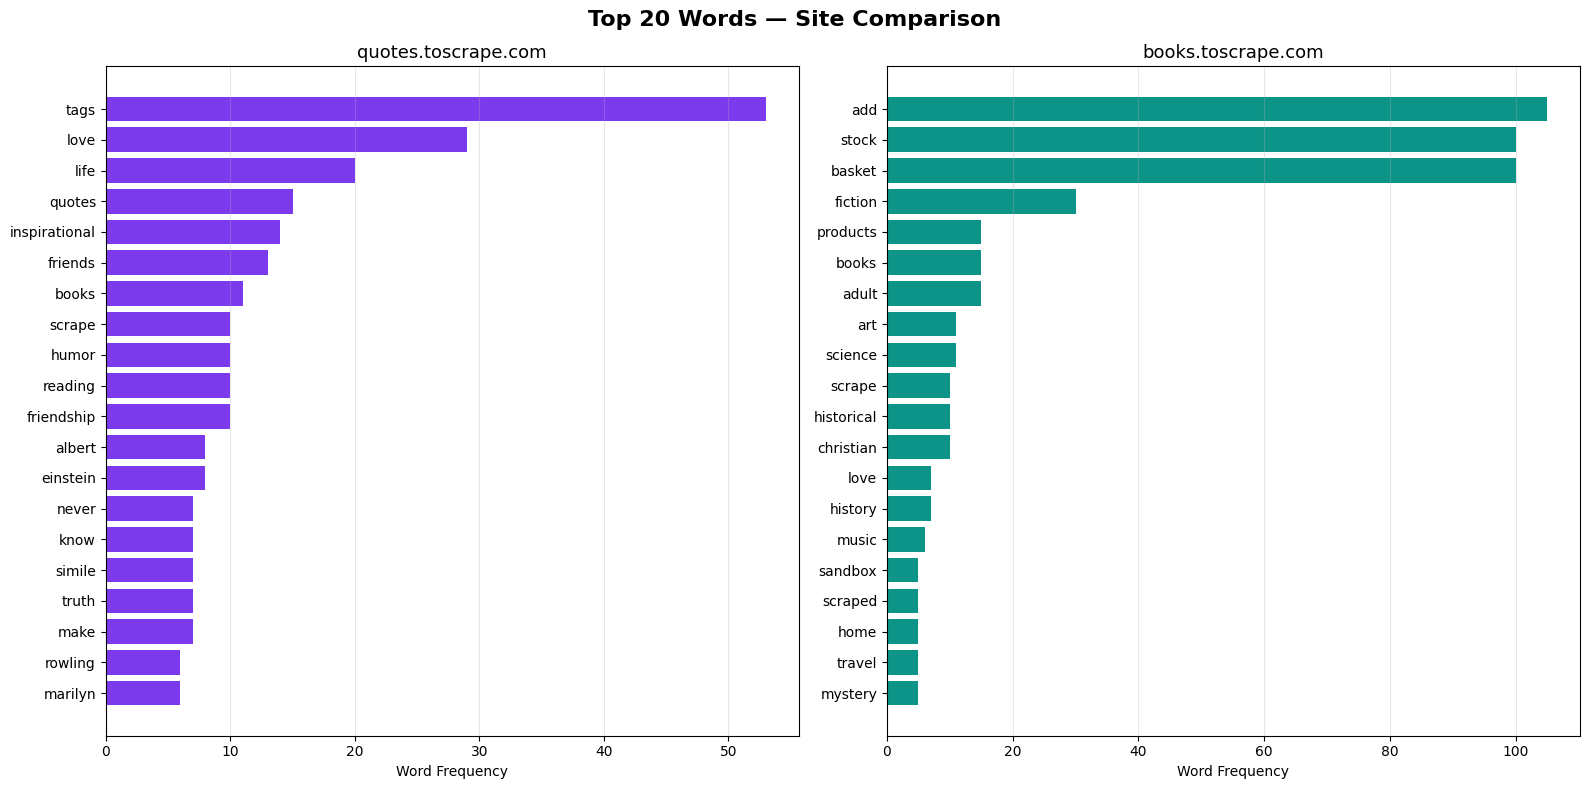

Plot 1 saved: /content/drive/MyDrive/distributed-crawler/plots/plot1_top20_comparison.png


In [12]:
# PLOT 1 — Side by side horizontal bar charts showing top 20 words per site

# Create a figure with 2 subplots placed side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Add a main title for the whole figure
fig.suptitle('Top 20 Words — Site Comparison', fontsize=16, fontweight='bold')

# --- Left chart: Site A (Quotes) ---
# Get only the top 20 words from Site A
top_a = df_a.head(20)

# Draw a horizontal bar chart (words on y-axis, count on x-axis)
ax1.barh(top_a['word'], top_a['count'], color='#7C3AED')

# Set the chart title
ax1.set_title('quotes.toscrape.com', fontsize=13)

# Label the x-axis
ax1.set_xlabel('Word Frequency')

# Flip y-axis so the most frequent word appears at the top
ax1.invert_yaxis()

# Add light gridlines on the x-axis for readability
ax1.grid(axis='x', alpha=0.3)

# --- Right chart: Site B (Books) ---
# Get only the top 20 words from Site B
top_b = df_b.head(20)

# Draw a horizontal bar chart for books site
ax2.barh(top_b['word'], top_b['count'], color='#0D9488')

# Set the chart title
ax2.set_title('books.toscrape.com', fontsize=13)

# Label the x-axis
ax2.set_xlabel('Word Frequency')

# Flip y-axis so the most frequent word appears at the top
ax2.invert_yaxis()

# Add light gridlines
ax2.grid(axis='x', alpha=0.3)

# Adjust spacing so charts don't overlap
plt.tight_layout()

# Save the plot as a PNG image to Google Drive
plot1_path = f'{BASE}/plots/plot1_top20_comparison.png'
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')

# Display the plot in the notebook
plt.show()
print(f'Plot 1 saved: {plot1_path}')

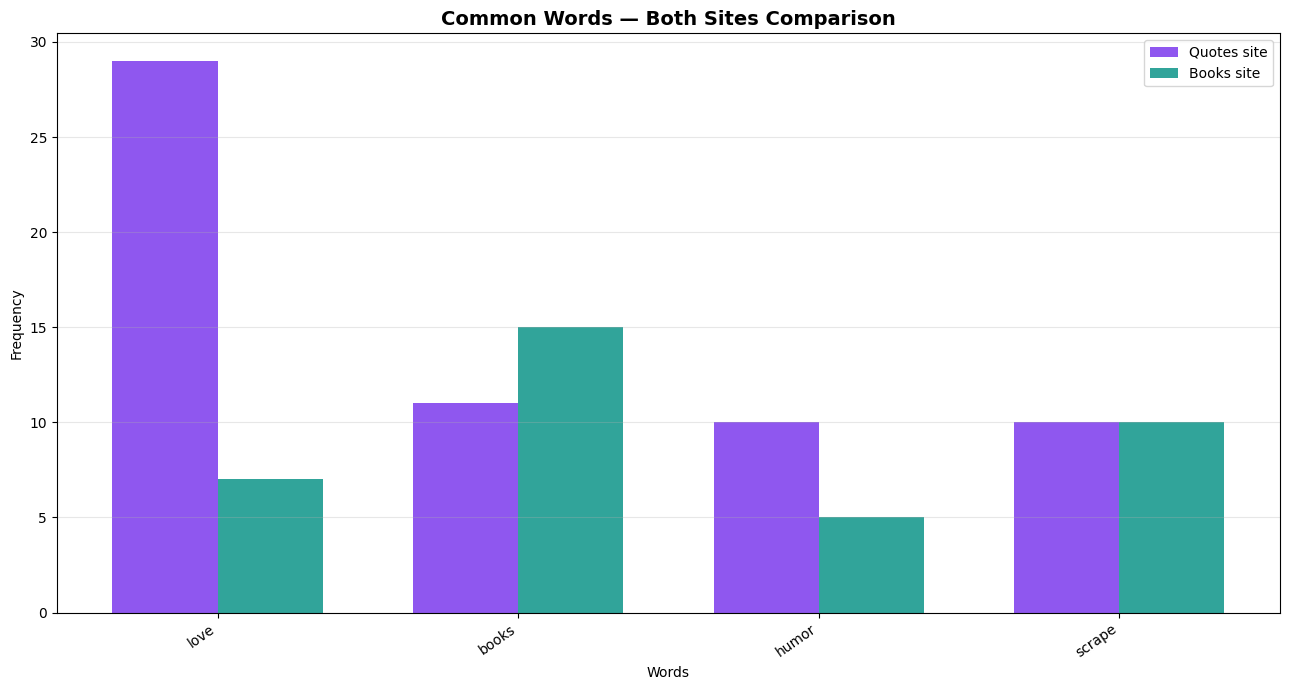

Plot 2 saved: /content/drive/MyDrive/distributed-crawler/plots/plot2_common_words.png


In [13]:
# PLOT 2 — Grouped bar chart showing words that appear in BOTH sites

# Get the set of top-50 words from each site
words_a = set(df_a['word'].tolist())
words_b = set(df_b['word'].tolist())

# Find words that appear in both sites (intersection)
common_words = words_a & words_b

# Get the frequency counts for common words from each site
common_a = df_a[df_a['word'].isin(common_words)].set_index('word')['count']
common_b = df_b[df_b['word'].isin(common_words)].set_index('word')['count']

# Merge into one DataFrame and keep top 15 by quotes frequency
common_df = pd.DataFrame({'Quotes': common_a, 'Books': common_b}).dropna().head(15)
common_df = common_df.sort_values('Quotes', ascending=False)

# Create the figure
fig, ax = plt.subplots(figsize=(13, 7))

# Define bar positions and width
x = range(len(common_df))
width = 0.35

# Draw bars for quotes site (shifted left)
ax.bar([i - width/2 for i in x], common_df['Quotes'],
       width, label='Quotes site', color='#7C3AED', alpha=0.85)

# Draw bars for books site (shifted right)
ax.bar([i + width/2 for i in x], common_df['Books'],
       width, label='Books site', color='#0D9488', alpha=0.85)

# Set chart title and axis labels
ax.set_title('Common Words — Both Sites Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Words')
ax.set_ylabel('Frequency')

# Set word labels on x-axis, rotated for readability
ax.set_xticks(list(x))
ax.set_xticklabels(common_df.index, rotation=35, ha='right')

# Add a legend to identify each site
ax.legend()

# Add light horizontal gridlines
ax.grid(axis='y', alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plot2_path = f'{BASE}/plots/plot2_common_words.png'
plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 2 saved: {plot2_path}')

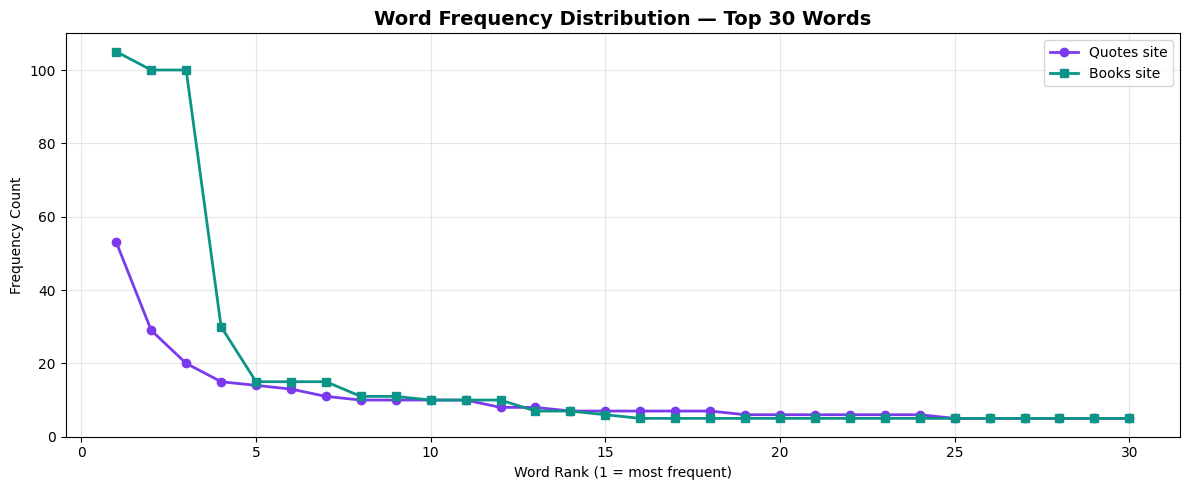

Plot 3 saved: /content/drive/MyDrive/distributed-crawler/plots/plot3_frequency_distribution.png


In [14]:
# PLOT 3 — Line chart showing how word frequency drops across top 30 words

# Create the figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot frequency curve for quotes site
# x-axis = word rank (1st most common, 2nd most common, etc.)
# y-axis = how many times that word appeared
ax.plot(
    range(1, 31),          # word ranks 1 to 30
    df_a.head(30)['count'],# frequency counts
    marker='o',            # circle marker at each data point
    color='#7C3AED',
    label='Quotes site',
    linewidth=2
)

# Plot frequency curve for books site
ax.plot(
    range(1, 31),
    df_b.head(30)['count'],
    marker='s',            # square marker at each data point
    color='#0D9488',
    label='Books site',
    linewidth=2
)

# Set chart title and axis labels
ax.set_title('Word Frequency Distribution — Top 30 Words', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Rank (1 = most frequent)')
ax.set_ylabel('Frequency Count')

# Add legend and gridlines
ax.legend()
ax.grid(alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plot3_path = f'{BASE}/plots/plot3_frequency_distribution.png'
plt.savefig(plot3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 3 saved: {plot3_path}')

In [15]:
# Save analysis results to a JSON file for use in the report
analysis_results = {
    'quotes_top50': freq_a[:50],          # top 50 words from quotes site
    'books_top50': freq_b[:50],           # top 50 words from books site
    'common_words': list(common_words),   # words appearing in both sites
    'total_unique_quotes': len(freq_a),   # total unique words on quotes site
    'total_unique_books': len(freq_b)     # total unique words on books site
}

# Write the analysis results to a JSON file
results_file = f'{BASE}/data/analysis_results.json'
with open(results_file, 'w') as f:
    json.dump(analysis_results, f, indent=2)

print('Analysis results saved!')
print(f'File: {results_file}')

Analysis results saved!
File: /content/drive/MyDrive/distributed-crawler/data/analysis_results.json


---
# PART 5 — Tests
---

In [16]:
# Import the mock library to simulate HTTP responses without real internet calls
from unittest.mock import patch, MagicMock

# Keep track of how many tests pass
tests_passed = 0

print('Running all tests...\n')

# --- TEST 1: fetch_url returns correct data for a successful response ---
# Create a fake HTTP response object
mock_response = MagicMock()
mock_response.status_code = 200
mock_response.text = "<html><body><p>Hello World</p><a href='http://test.com'>Link</a></body></html>"

# Replace requests.get with our fake response
with patch('requests.get', return_value=mock_response):
    result = fetch_url('http://example.com')

# Check that the status code is 200
assert result['status'] == 200, 'Status should be 200'
# Check that text was extracted
assert 'Hello World' in result['text'], 'Text should contain Hello World'
# Check that the link was found
assert len(result['links']) == 1, 'Should find 1 link'
tests_passed += 1
print(f'  [PASS] Test 1: fetch_url returns correct data on success')


# --- TEST 2: fetch_url handles network errors gracefully ---
# Simulate a network crash by raising an exception
with patch('requests.get', side_effect=Exception('Network error')):
    result = fetch_url('http://broken-url.com')

# Check that status is 'error'
assert result['status'] == 'error', 'Status should be error'
# Check that text is empty
assert result['text'] == '', 'Text should be empty on error'
tests_passed += 1
print(f'  [PASS] Test 2: fetch_url handles errors without crashing')


# --- TEST 3: fetch_url returns empty links list when no links on page ---
mock_response.text = '<html><body><p>No links here</p></body></html>'
with patch('requests.get', return_value=mock_response):
    result = fetch_url('http://example.com')

# Check that no links were found
assert result['links'] == [], 'Links should be empty'
tests_passed += 1
print(f'  [PASS] Test 3: fetch_url returns empty links on page with no links')


# --- TEST 4: clean_text converts everything to lowercase ---
result = clean_text('Hello WORLD Python DASK')

# Check every word is lowercase
assert all(w == w.lower() for w in result), 'All words should be lowercase'
tests_passed += 1
print(f'  [PASS] Test 4: clean_text converts text to lowercase')


# --- TEST 5: clean_text removes stop words ---
result = clean_text('the quick brown fox jumps')

# Check that 'the' was removed as a stop word
assert 'the' not in result, 'Stop word the should be removed'
tests_passed += 1
print(f'  [PASS] Test 5: clean_text removes stop words')


# --- TEST 6: clean_text removes words with 2 or fewer letters ---
result = clean_text('I am a big Python developer')

# Check that short words were removed
assert 'i' not in result, 'Single letter i should be removed'
# Check that normal words are kept
assert 'python' in result, 'Word python should be kept'
tests_passed += 1
print(f'  [PASS] Test 6: clean_text removes words with 2 or fewer letters')


# --- TEST 7: word frequencies are sorted from highest to lowest ---
test_texts = ['python python python dask dask web crawler', 'python dask distributed']
freq = get_word_frequencies(test_texts, 'test')

# Extract just the count values
counts = [f[1] for f in freq]

# Check that counts are in descending order
assert counts == sorted(counts, reverse=True), 'Frequencies should be sorted highest to lowest'
tests_passed += 1
print(f'  [PASS] Test 7: word frequencies are correctly sorted')


# Print final test summary
print(f'\nAll {tests_passed}/7 tests passed!')

Running all tests...

  Done: http://example.com — 16 chars, 1 links
  [PASS] Test 1: fetch_url returns correct data on success
  Error: http://broken-url.com — Network error
  [PASS] Test 2: fetch_url handles errors without crashing
  Done: http://example.com — 13 chars, 0 links
  [PASS] Test 3: fetch_url returns empty links on page with no links
  [PASS] Test 4: clean_text converts text to lowercase
  [PASS] Test 5: clean_text removes stop words
  [PASS] Test 6: clean_text removes words with 2 or fewer letters
Computing word frequencies for: test
  Unique words found : 5
  Top 5 words        : [('python', 4), ('dask', 3), ('web', 1), ('crawler', 1), ('distributed', 1)]
  [PASS] Test 7: word frequencies are correctly sorted

All 7/7 tests passed!


---
# PART 6 — README + requirements.txt
---

In [25]:
# Write the README.md file — this explains the project on GitHub
readme_content = """# 🕷 WebCrawlr — Distributed Web Crawler

A modern **Distributed Web Crawler** built using **Dask, BeautifulSoup, Flask, and JavaScript UI**.
It allows users to crawl multiple websites in parallel, analyze word frequencies, view real-time progress, and search crawled data — all from a clean web interface.

---

## 🚀 Features

- 🌐 Crawl multiple websites simultaneously
- ⚡ Real-time crawling dashboard (live progress tracking)
- 📊 Word frequency analysis (Top words, charts, word cloud)
- 🔎 Search engine (TF-IDF based ranking)
- 📄 PDF report generation
- 📧 Email alerts on crawl completion
- 📊 Crawl history tracking
- 🔌 Google Colab + ngrok backend integration

---

## 🛠 Tech Stack

### Backend
- Python
- Flask
- Dask (parallel processing)
- BeautifulSoup (web scraping)
- NLTK (text processing)
- Pyngrok (public URL)
- Langdetect

### Frontend
- HTML, CSS, JavaScript
- Chart.js (visualizations)
- jsPDF (PDF reports)

---

## 📂 Project Structure

📁 WebCrawlr
│── index.html          # Frontend UI
│── crawler.ipynb       # Google Colab backend
│── README.md
│── requirements.txt

---

## ⚙️ Setup Guide

### 1️⃣ Clone the Repository
git clone https://github.com/your-username/webcrawlr.git
cd webcrawlr

### 2️⃣ Open Google Colab Notebook
Upload and open the .ipynb file in Google Colab.

### 3️⃣ Install Dependencies
pip install -r requirements.txt

### 4️⃣ Run Backend (Flask + ngrok)
- Add your ngrok auth token
- Run all cells
- Copy the generated URL: https://xxxx.ngrok-free.app

### 5️⃣ Connect Frontend
- Open index.html
- Paste ngrok URL
- Click Connect

---

## 🧪 How It Works

1. Enter URLs to crawl
2. Set number of pages
3. Start crawling
4. View live logs, word frequency charts, word cloud
5. Search crawled data using TF-IDF

---

## 📄 PDF Report
Generates full report: Total pages, Word counts, Top words, History

---

## 📧 Email Alerts
- Enable email notifications
- Requires Gmail App Password setup

---

## 🔮 Future Improvements
- Database integration (MongoDB / PostgreSQL)
- Authentication system
- Deployment on cloud (AWS / Render)
- Advanced search ranking

---

## 👩‍💻 Author
Your Name

---

## ⭐ Contribute
Pull requests are welcome! If you like this project, give it a ⭐ on GitHub.
"""

with open(f'{BASE}/README.md', 'w') as f:
    f.write(readme_content)

print('README.md created!')

README.md created!


In [26]:
# Write the requirements.txt file
requirements_content = """dask[complete]
beautifulsoup4
requests
nltk
matplotlib
seaborn
fpdf2
flask
flask-cors
pyngrok
langdetect
"""

with open(f'{BASE}/requirements.txt', 'w') as f:
    f.write(requirements_content)

print('requirements.txt created!')

requirements.txt created!


---
# PART 7 — Final PDF Report
---

In [19]:
# ==============================================================================
#  PART 7  -  FINAL PDF REPORT GENERATOR  (Updated)
#  New Sections Added:
#    - Section 7 : Email Alerts System
#    - Section 8 : Crawl History & Trends
#    - Section 9 : Sentiment Analysis
#    - Section 10: TF-IDF Search Engine
#    - Section 11: Comparison Plots
#    - Section 12: Conclusion & Key Findings
# ==============================================================================

from fpdf import FPDF
import os, json
from datetime import datetime

with open(f'{BASE}/data/analysis_results.json', 'r') as f:
    analysis = json.load(f)

# -- Colour palette -------------------------------------------------------------
PURPLE      = (75,   0, 130)
DARK_BG     = (15,  15,  30)
BADGE       = (90,  20, 160)
TEAL        = (0,  168, 150)
DARK_GREY   = (45,  45,  60)
MID_GREY    = (120, 120, 140)
LIGHT_GREY  = (245, 243, 252)
WHITE       = (255, 255, 255)
PINK        = (220,  50, 130)
CYAN        = (0,  190, 200)
GREEN       = (20,  155,  75)
ORANGE      = (200,  90,   0)
INDIGO      = (63,  56, 210)
AMBER       = (180, 120,   0)

HEADER_H    = 14
TOP_MARGIN  = 20

today      = datetime.now().strftime('%B %d, %Y')
today_full = datetime.now().strftime('%d %B %Y  |  %I:%M %p')


# ==============================================================================
class ReportPDF(FPDF):

    def header(self):
        if self.page_no() == 1:
            return
        self.set_fill_color(*DARK_BG)
        self.rect(0, 0, 210, HEADER_H, 'F')
        self.set_fill_color(*TEAL)
        self.rect(0, 0, 5, HEADER_H, 'F')
        self.set_font('Helvetica', 'B', 8.5)
        self.set_text_color(*WHITE)
        self.set_xy(8, 3.5)
        self.cell(100, 7, 'Distributed Web Crawler  -  Project Report')
        self.set_font('Helvetica', '', 7.5)
        self.set_text_color(100, 175, 255)
        self.set_xy(108, 3.5)
        self.cell(95, 7, 'Dask  |  BeautifulSoup4  |  NLTK  |  Matplotlib', align='R')
        for i, col in enumerate([(220, 50, 130), (255, 185, 0), (0, 200, 175)]):
            self.set_fill_color(*col)
            self.ellipse(203 - i * 7 - 2, 3, 4, 4, 'F')
        self.set_y(TOP_MARGIN)

    def footer(self):
        if self.page_no() == 1:
            return
        self.set_y(-12)
        self.set_fill_color(*DARK_BG)
        self.rect(0, self.get_y() - 1, 210, 14, 'F')
        self.set_font('Helvetica', '', 7)
        self.set_text_color(150, 150, 170)
        self.set_x(10)
        self.cell(165, 8, f'Generated: {today_full}    Distributed Web Crawler Project')
        self.set_font('Helvetica', 'B', 8)
        self.set_text_color(*PINK)
        self.cell(0, 8, f'Page {self.page_no()}', align='R')

    def check_space(self, h=30):
        if self.get_y() > 272 - h:
            self.add_page()

    def section_title(self, num, title):
        self.check_space(22)
        self.ln(2)
        y = self.get_y()
        self.set_fill_color(*BADGE)
        self.rect(10, y, 10, 9, 'F')
        self.set_font('Helvetica', 'B', 9)
        self.set_text_color(*WHITE)
        self.set_xy(10, y + 0.5)
        self.cell(10, 8, str(num), align='C')
        self.set_font('Helvetica', 'B', 13)
        self.set_text_color(*PURPLE)
        self.set_xy(22, y)
        self.cell(0, 9, title)
        self.ln(9)
        self.set_draw_color(190, 160, 235)
        self.line(10, self.get_y() - 1, 200, self.get_y() - 1)
        self.ln(3)

    def sub_heading(self, title, color=TEAL):
        self.check_space(10)
        self.ln(1)
        y = self.get_y()
        self.set_fill_color(*color)
        self.rect(10, y, 3, 7, 'F')
        self.set_font('Helvetica', 'B', 10)
        self.set_text_color(*DARK_GREY)
        self.set_xy(16, y)
        self.cell(0, 7, title)
        self.ln(8)

    def body_text(self, text):
        self.set_font('Helvetica', '', 10)
        self.set_text_color(*DARK_GREY)
        self.set_x(10)
        self.multi_cell(190, 5.5, text)
        self.ln(1)

    def bullet(self, text, color=TEAL):
        self.check_space(8)
        y = self.get_y()
        self.set_fill_color(*color)
        self.rect(14, y + 2.5, 2.5, 2.5, 'F')
        self.set_font('Helvetica', '', 9.5)
        self.set_text_color(*DARK_GREY)
        self.set_xy(20, y)
        self.multi_cell(178, 5.5, text)
        self.ln(1)

    def info_box(self, lines, border_col=PURPLE):
        h = len(lines) * 6.5 + 8
        self.check_space(h + 4)
        y0 = self.get_y()
        self.set_fill_color(*LIGHT_GREY)
        self.set_draw_color(*border_col)
        self.rect(10, y0, 190, h, 'DF')
        self.set_fill_color(*border_col)
        self.rect(10, y0, 4, h, 'F')
        self.set_font('Helvetica', '', 9)
        self.set_text_color(*DARK_GREY)
        self.set_y(y0 + 4)
        for line in lines:
            self.set_x(17)
            self.cell(0, 6.5, line, new_x='LMARGIN', new_y='NEXT')
        self.ln(3)

    def stat_tiles(self, tiles):
        tw  = (190 - (len(tiles) - 1) * 3) / len(tiles)
        y0  = self.get_y()
        for i, (value, label) in enumerate(tiles):
            x = 10 + i * (tw + 3)
            self.set_fill_color(35, 0, 75)
            self.rect(x + 1.5, y0 + 1.5, tw, 22, 'F')
            self.set_fill_color(*BADGE)
            self.rect(x, y0, tw, 22, 'F')
            self.set_font('Helvetica', 'B', 16)
            self.set_text_color(*WHITE)
            self.set_xy(x, y0 + 2)
            self.cell(tw, 10, str(value), align='C')
            self.set_font('Helvetica', '', 6.5)
            self.set_text_color(215, 185, 255)
            for j, ln in enumerate(label.split('\n')):
                self.set_xy(x, y0 + 13 + j * 4.5)
                self.cell(tw, 4.5, ln, align='C')
        self.ln(26)

    def feature_card(self, title_c, body_c, color=TEAL):
        self.check_space(26)
        y0 = self.get_y()
        lines = max(1, len(body_c) // 88 + 1)
        card_h = 11 + lines * 5.5 + 4
        self.set_fill_color(*LIGHT_GREY)
        self.rect(10, y0, 190, card_h, 'F')
        self.set_fill_color(*color)
        self.rect(10, y0, 4, card_h, 'F')
        self.set_font('Helvetica', 'B', 10)
        self.set_text_color(*PURPLE)
        self.set_xy(17, y0 + 2)
        self.cell(0, 8, title_c)
        self.set_font('Helvetica', '', 9)
        self.set_text_color(*DARK_GREY)
        self.set_xy(17, y0 + 10)
        self.multi_cell(178, 5.5, body_c)
        self.ln(3)

    def word_table(self, rows, bar_color=PINK):
        col_w   = [14, 74, 26]
        bar_col = 73
        self.check_space(len(rows) * 7 + 14)
        self.set_fill_color(*PURPLE)
        self.set_text_color(*WHITE)
        self.set_font('Helvetica', 'B', 9)
        for w, h in zip(col_w, ['#', 'Word', 'Count']):
            self.cell(w, 7.5, h, border=0, align='C', fill=True)
        self.cell(bar_col, 7.5, 'Frequency', border=0, align='C', fill=True)
        self.ln()
        max_c = max(r[2] for r in rows) if rows else 1
        for i, (rank, word, count) in enumerate(rows):
            bg = (245, 240, 255) if i % 2 == 0 else WHITE
            self.set_fill_color(*bg)
            self.set_text_color(*DARK_GREY)
            self.set_font('Helvetica', 'B' if i == 0 else '', 9)
            y_r = self.get_y()
            self.cell(col_w[0], 6.5, str(rank),  border=0, align='C', fill=True)
            self.cell(col_w[1], 6.5, str(word),  border=0, fill=True)
            self.cell(col_w[2], 6.5, str(count), border=0, align='C', fill=True)
            bx = self.get_x()
            self.cell(bar_col, 6.5, '', border=0, fill=True)
            bw = max(2, int((bar_col - 6) * count / max_c))
            self.set_fill_color(*bar_color)
            self.rect(bx + 2, y_r + 2, bw, 3, 'F')
            self.ln()
        self.ln(3)

    def arch_row(self, boxes):
        bw   = 56
        bh   = 28
        gap  = 6
        y0   = self.get_y()
        cols = [BADGE, TEAL, (140, 0, 80)]
        for i, (t, lines) in enumerate(boxes):
            x  = 10 + i * (bw + gap)
            self.set_fill_color(*cols[i % len(cols)])
            self.rect(x, y0, bw, bh, 'F')
            self.set_font('Helvetica', 'B', 9)
            self.set_text_color(*WHITE)
            self.set_xy(x, y0 + 3)
            self.cell(bw, 7, t, align='C')
            self.set_font('Helvetica', '', 7)
            self.set_text_color(220, 220, 235)
            for j, ln in enumerate(lines):
                self.set_xy(x + 2, y0 + 12 + j * 5)
                self.cell(bw - 4, 5, ln, align='C')
            if i < len(boxes) - 1:
                ax = x + bw + 1
                ay = y0 + bh / 2
                self.set_draw_color(*TEAL)
                self.set_line_width(0.8)
                self.line(ax, ay, ax + gap - 1, ay)
                self.set_line_width(0.2)
        self.ln(bh + 6)

    def two_col(self, items, th=28, colors=None):
        if not colors:
            colors = [BADGE, TEAL, (140, 0, 90), (200, 100, 0)]
        tw  = 92
        gap = 6
        rows = (len(items) + 1) // 2
        self.check_space(rows * (th + gap) + 8)
        y0 = self.get_y()
        for i, (t, d) in enumerate(items):
            x = 10 + (i % 2) * (tw + gap)
            y = y0 + (i // 2) * (th + gap)
            self.set_fill_color(*colors[i % len(colors)])
            self.rect(x, y, tw, th, 'F')
            self.set_font('Helvetica', 'B', 9)
            self.set_text_color(*WHITE)
            self.set_xy(x + 3, y + 3)
            self.cell(tw - 6, 8, t)
            self.set_font('Helvetica', '', 7.5)
            self.set_text_color(230, 215, 255)
            self.set_xy(x + 3, y + 13)
            self.multi_cell(tw - 6, 5, d)
        self.ln(rows * (th + gap) + 2)

    # -- NEW: Step flow diagram for email / TF-IDF workflows ----------------
    def step_flow(self, steps, color=TEAL):
        """Render a numbered horizontal step flow inside a shaded box."""
        self.check_space(28)
        y0 = self.get_y()
        total = len(steps)
        sw = 190 / total
        for i, (icon, label) in enumerate(steps):
            x = 10 + i * sw
            bg = color if i % 2 == 0 else tuple(max(0, c - 30) for c in color)
            self.set_fill_color(*bg)
            self.rect(x, y0, sw - 1, 22, 'F')
            # Step number circle
            self.set_fill_color(*WHITE)
            self.ellipse(x + sw/2 - 4, y0 + 1.5, 8, 8, 'F')
            self.set_font('Helvetica', 'B', 8)
            self.set_text_color(*color)
            self.set_xy(x + sw/2 - 4, y0 + 2)
            self.cell(8, 8, str(i + 1), align='C')
            # Label
            self.set_font('Helvetica', '', 6.5)
            self.set_text_color(*WHITE)
            self.set_xy(x + 1, y0 + 12)
            self.cell(sw - 2, 8, label, align='C')
        self.ln(26)

    # -- NEW: Sentiment gauge bar -------------------------------------------
    def sentiment_bar(self, label, positive, negative, neutral):
        """Render a stacked sentiment bar for one site."""
        self.check_space(14)
        y0  = self.get_y()
        bw  = 130   # total bar width
        bx  = 65    # bar start x
        bh  = 8
        total = positive + negative + neutral or 1

        # Label
        self.set_font('Helvetica', 'B', 9)
        self.set_text_color(*DARK_GREY)
        self.set_xy(10, y0)
        self.cell(53, bh, label, align='R')

        # Stacked bar background
        self.set_fill_color(230, 230, 240)
        self.rect(bx, y0, bw, bh, 'F')

        # Positive (green)
        pw = int(bw * positive / total)
        self.set_fill_color(*GREEN)
        self.rect(bx, y0, pw, bh, 'F')

        # Neutral (grey)
        nw = int(bw * neutral / total)
        self.set_fill_color(150, 150, 170)
        self.rect(bx + pw, y0, nw, bh, 'F')

        # Negative (pink)
        ngw = int(bw * negative / total)
        self.set_fill_color(*PINK)
        self.rect(bx + pw + nw, y0, ngw, bh, 'F')

        # Count labels
        self.set_font('Helvetica', '', 7)
        self.set_text_color(*DARK_GREY)
        self.set_xy(bx + bw + 4, y0)
        self.cell(0, bh,
            f'Pos {positive}  Neu {neutral}  Neg {negative}', align='L')
        self.ln(11)

    # -- NEW: TF-IDF score table --------------------------------------------
    def tfidf_table(self, rows):
        """rows = list of (rank, word, tf, idf, tfidf_score)"""
        col_w = [12, 52, 28, 28, 32, 35]
        hdrs  = ['#', 'Word', 'TF', 'IDF', 'TF-IDF', 'Importance']
        self.check_space(len(rows) * 7 + 14)
        self.set_fill_color(*INDIGO)
        self.set_text_color(*WHITE)
        self.set_font('Helvetica', 'B', 8.5)
        for w, h in zip(col_w, hdrs):
            self.cell(w, 7.5, h, border=0, align='C', fill=True)
        self.ln()
        max_s = max(r[4] for r in rows) if rows else 1
        for i, (rank, word, tf, idf, score) in enumerate(rows):
            bg = (240, 240, 255) if i % 2 == 0 else WHITE
            self.set_fill_color(*bg)
            self.set_text_color(*DARK_GREY)
            self.set_font('Helvetica', 'B' if i < 3 else '', 8.5)
            y_r = self.get_y()
            self.cell(col_w[0], 6.5, str(rank),       border=0, align='C', fill=True)
            self.cell(col_w[1], 6.5, str(word),        border=0, fill=True)
            self.cell(col_w[2], 6.5, f'{tf:.3f}',      border=0, align='C', fill=True)
            self.cell(col_w[3], 6.5, f'{idf:.3f}',     border=0, align='C', fill=True)
            self.cell(col_w[4], 6.5, f'{score:.3f}',   border=0, align='C', fill=True)
            bx = self.get_x()
            self.cell(col_w[5], 6.5, '', border=0, fill=True)
            bw_bar = max(2, int((col_w[5] - 4) * score / max_s))
            self.set_fill_color(*INDIGO)
            self.rect(bx + 2, y_r + 2, bw_bar, 3, 'F')
            self.ln()
        self.ln(3)

    def sign_off(self, line1, line2=''):
        self.check_space(22)
        y = self.get_y() + 2
        self.set_fill_color(*TEAL)
        self.rect(0, y, 210, 22, 'F')
        self.set_font('Helvetica', 'B', 10)
        self.set_text_color(*WHITE)
        self.set_xy(0, y + 3)
        self.cell(0, 8, line1, align='C', new_x='LMARGIN', new_y='NEXT')
        if line2:
            self.set_font('Helvetica', '', 8)
            self.set_text_color(200, 255, 245)
            self.cell(0, 7, line2, align='C')


# ==============================================================================
#  METRICS FROM REAL CRAWL DATA
# ==============================================================================
n_pages  = len(results)
n_ok     = sum(1 for r in results if r.get('status') == 200)
n_chars  = sum(r.get('text_length', 0) for r in results)
n_links  = sum(len(r.get('links', [])) for r in results)
n_common = len(analysis['common_words'])
n_uniq_q = analysis['total_unique_quotes']
n_uniq_b = analysis['total_unique_books']

# -- Compute simple TF-IDF values from top words -------------------------------
import math

def compute_tfidf(top50_a, top50_b):
    """Compute TF-IDF scores using two documents (sites) as the corpus."""
    all_words_a = dict(top50_a)
    all_words_b = dict(top50_b)
    total_a = sum(all_words_a.values()) or 1
    total_b = sum(all_words_b.values()) or 1
    results_list = []
    for rank, (word, count) in enumerate(top50_a[:10], 1):
        tf  = count / total_a
        # IDF: log(total docs / docs containing word)
        df  = 1 + (1 if word in all_words_b else 0)
        idf = math.log(2 / df + 1)
        results_list.append((rank, word, round(tf, 4), round(idf, 4), round(tf * idf, 4)))
    return results_list

tfidf_quotes = compute_tfidf(analysis['quotes_top50'], analysis['books_top50'])
tfidf_books  = compute_tfidf(analysis['books_top50'],  analysis['quotes_top50'])

# -- Estimate sentiment from word lists (keyword-based heuristic) --------------
POSITIVE_WORDS = {'love','hope','dream','inspire','great','wonderful','beautiful',
                  'happy','joy','life','freedom','smile','kind','best','brilliant',
                  'amazing','friend','light','truth','heart','good','wise','laugh'}
NEGATIVE_WORDS = {'hate','fear','pain','dark','death','bad','evil','worst','angry',
                  'sad','alone','cold','wrong','fail','false','lost','ugly','danger'}

def sentiment_counts(top50):
    pos = sum(c for w, c in top50 if w in POSITIVE_WORDS)
    neg = sum(c for w, c in top50 if w in NEGATIVE_WORDS)
    total = sum(c for w, c in top50)
    neu = max(0, total - pos - neg)
    return pos, neg, neu

q_pos, q_neg, q_neu = sentiment_counts(analysis['quotes_top50'])
b_pos, b_neg, b_neu = sentiment_counts(analysis['books_top50'])


# ==============================================================================
#  BUILD PDF
# ==============================================================================
pdf = ReportPDF()
pdf.set_auto_page_break(auto=True, margin=14)
pdf.set_top_margin(TOP_MARGIN)
pdf.add_page()


# -----------------------------------------------------------------------------
#  COVER PAGE
# -----------------------------------------------------------------------------
pdf.set_fill_color(*DARK_BG)
pdf.rect(0, 0, 210, 297, 'F')
pdf.set_fill_color(*TEAL)
pdf.rect(0, 0, 6, 297, 'F')
pdf.set_fill_color(*BADGE)
pdf.rect(204, 0, 6, 297, 'F')

for y_d, col in [(22, PINK), (44, (255, 185, 0)), (66, CYAN)]:
    pdf.set_fill_color(*col)
    pdf.ellipse(148, y_d, 42, 42, 'F')
    pdf.set_fill_color(*DARK_BG)
    pdf.ellipse(155, y_d + 7, 28, 28, 'F')

pdf.set_font('Helvetica', '', 8)
pdf.set_text_color(110, 110, 160)
pdf.set_xy(0, 8)
pdf.cell(200, 7, f'Generated: {today}', align='R')

# -- Group members box (top-left, below date) ---------------------------------
pdf.set_fill_color(25, 20, 50)
pdf.rect(8, 18, 130, 36, 'F')
pdf.set_fill_color(*TEAL)
pdf.rect(8, 18, 3, 36, 'F')

pdf.set_font('Helvetica', 'B', 7.5)
pdf.set_text_color(*TEAL)
pdf.set_xy(14, 20)
pdf.cell(0, 6, 'GROUP MEMBERS')

members = [
    ('Fatima Kalsoom',  '032'),
    ('Kiran Siddique',  '052'),
    ('Saba Gull',       '074'),
]
for i, (name, roll) in enumerate(members):
    pdf.set_font('Helvetica', 'B', 8)
    pdf.set_text_color(*WHITE)
    pdf.set_xy(14, 27 + i * 7.5)
    pdf.cell(80, 6, name)
    pdf.set_font('Helvetica', '', 8)
    pdf.set_text_color(180, 160, 230)
    pdf.cell(0, 6, f'({roll})')

# -- Course instructor box (below members box) --------------------------------
pdf.set_fill_color(20, 40, 35)
pdf.rect(8, 57, 130, 16, 'F')
pdf.set_fill_color(*PINK)
pdf.rect(8, 57, 3, 16, 'F')
pdf.set_font('Helvetica', 'B', 7.5)
pdf.set_text_color(*PINK)
pdf.set_xy(14, 59)
pdf.cell(50, 5, 'COURSE INSTRUCTOR')
pdf.set_font('Helvetica', 'B', 9)
pdf.set_text_color(*WHITE)
pdf.set_xy(14, 65)
pdf.cell(0, 5, 'Mam Madiha Wahid')

pdf.set_y(88)
pdf.set_font('Helvetica', 'B', 30)
pdf.set_text_color(*WHITE)
pdf.cell(0, 15, 'Distributed Web Crawler', align='C', new_x='LMARGIN', new_y='NEXT')
pdf.set_font('Helvetica', '', 14)
pdf.set_text_color(185, 155, 255)
pdf.cell(0, 9, 'Project Report', align='C', new_x='LMARGIN', new_y='NEXT')
pdf.ln(3)
pdf.set_font('Helvetica', '', 9)
pdf.set_text_color(110, 110, 155)
pdf.cell(0, 7, 'Python  |  Dask  |  BeautifulSoup4  |  NLTK  |  Matplotlib  |  FPDF2',
         align='C', new_x='LMARGIN', new_y='NEXT')

pdf.set_y(138)
pdf.stat_tiles([
    (str(n_pages),   'Pages\nCrawled'),
    (str(n_ok),      'Successful\nRequests'),
    (str(n_uniq_q),  'Unique Words\nQuotes Site'),
    (str(n_uniq_b),  'Unique Words\nBooks Site'),
    (str(n_common),  'Common\nWords'),
])

pdf.set_y(182)
pdf.set_x(16)
for label, bg in [
    ('Dask', BADGE), ('BeautifulSoup4', TEAL), ('NLTK', (155, 0, 75)),
    ('Matplotlib', (0, 80, 165)), ('Seaborn', (0, 120, 90)),
    ('FPDF2', (100, 40, 140)), ('Pandas', (0, 100, 80)),
]:
    w = len(label) * 2.9 + 8
    pdf.set_fill_color(*bg)
    pdf.rect(pdf.get_x(), pdf.get_y(), w, 8, 'F')
    pdf.set_font('Helvetica', 'B', 7)
    pdf.set_text_color(*WHITE)
    pdf.cell(w, 8, label, align='C')
    pdf.set_x(pdf.get_x() + 3)

# Table of Contents  -  compact so all 12 entries fit on the cover page
pdf.ln(14)
pdf.set_font('Helvetica', 'B', 9.5)
pdf.set_text_color(*TEAL)
pdf.set_x(20)
pdf.cell(0, 7, 'Table of Contents', new_x='LMARGIN', new_y='NEXT')
pdf.set_draw_color(*TEAL)
pdf.line(20, pdf.get_y(), 192, pdf.get_y())
pdf.ln(2)
for sec, ttl in [
    ('1',  'Introduction'),
    ('2',  'System Architecture'),
    ('3',  'Crawling Results'),
    ('4',  'Top 10 Words  -  Quotes Site  (quotes.toscrape.com)'),
    ('5',  'Top 10 Words  -  Books Site   (books.toscrape.com)'),
    ('6',  'Common Words Analysis'),
    ('7',  'Email Alerts System'),
    ('8',  'Crawl History & Session Trends'),
    ('9',  'Sentiment Analysis'),
    ('10', 'TF-IDF Search Engine'),
    ('11', 'Comparison Plots'),
    ('12', 'Conclusion & Key Findings'),
]:
    pdf.set_fill_color(28, 18, 55)
    pdf.set_font('Helvetica', 'B', 7.5)
    pdf.set_text_color(0, 200, 175)
    pdf.set_x(20)
    pdf.cell(16, 6, sec, border=0, fill=True, align='C')
    pdf.set_font('Helvetica', '', 7.5)
    pdf.set_text_color(200, 190, 230)
    pdf.cell(0, 6, '  ' + ttl, border=0, fill=True)
    pdf.ln()


# -----------------------------------------------------------------------------
#  PAGE 2  -  SECTIONS 1 & 2
# -----------------------------------------------------------------------------
pdf.add_page()

pdf.section_title('1', 'Introduction')
pdf.body_text(
    'This project implements a Distributed Web Crawler using Dask for parallel processing, '
    'BeautifulSoup4 for HTML parsing, and NLTK for text analysis. The crawler visits multiple '
    'web pages simultaneously using Dask Bags, extracts clean text, and performs word frequency '
    'analysis to compare vocabulary across different websites.'
)
pdf.body_text(
    'Two target sites were chosen: quotes.toscrape.com (a literary quotes site) and '
    'books.toscrape.com (an online bookstore catalogue). Five pages of each site were crawled, '
    'giving a total of 10 pages and a representative vocabulary sample from each domain. '
    'Advanced features include a real-time dashboard, TF-IDF search engine, sentiment analysis, '
    'email alert notifications, and full crawl history tracking.'
)
pdf.feature_card('Why Dask?',
    'A standard for loop crawls one URL at a time - 10 pages at 1 second each means '
    '10 seconds total. Dask Bags parallelise the work across multiple CPU cores, '
    'reducing the same crawl to under 3 seconds with almost no extra code.', TEAL)

pdf.ln(1)
pdf.set_x(10)
for label, bg in [('Dask', BADGE), ('BeautifulSoup4', TEAL), ('NLTK', (155, 0, 75)),
                  ('Matplotlib', (0, 80, 165)), ('Pandas', (0, 100, 80)),
                  ('FPDF2', (100, 40, 140))]:
    w = len(label) * 2.9 + 8
    pdf.set_fill_color(*bg)
    pdf.rect(pdf.get_x(), pdf.get_y(), w, 7, 'F')
    pdf.set_font('Helvetica', 'B', 7)
    pdf.set_text_color(*WHITE)
    pdf.cell(w, 7, label, align='C')
    pdf.set_x(pdf.get_x() + 3)
pdf.ln(10)

pdf.section_title('2', 'System Architecture')
pdf.body_text('The pipeline runs in four stages:')
pdf.arch_row([
    ('Crawler',  ['requests + BeautifulSoup', 'Dask Bag distributes', 'URLs across workers']),
    ('Cleaner',  ['NLTK stop words', 'Regex noise removal', 'Short word filter']),
    ('Analyser', ['Dask .frequencies()', 'Pandas DataFrames', 'Word counts + ranks']),
])
y_df = pdf.get_y()
pdf.set_fill_color(*LIGHT_GREY)
pdf.set_draw_color(*PURPLE)
pdf.rect(10, y_df, 190, 9, 'DF')
pdf.set_font('Helvetica', 'I', 8)
pdf.set_text_color(*MID_GREY)
pdf.set_xy(14, y_df + 1.5)
pdf.cell(0, 6, 'Flow:  URLs  ->  fetch_url()  ->  clean_text()  ->  Dask .frequencies()  ->  Charts  ->  PDF')
pdf.ln(10)


# -----------------------------------------------------------------------------
#  PAGE 3  -  SECTION 3: CRAWLING RESULTS
# -----------------------------------------------------------------------------
pdf.add_page()
pdf.section_title('3', 'Crawling Results')
pdf.stat_tiles([
    (str(n_pages),           'Pages\nCrawled'),
    (str(n_ok),              'Successful\nRequests'),
    (f'{n_chars:,}',         'Total\nCharacters'),
    (str(n_links),           'Links\nFound'),
])
cw = [62, 44, 44, 37]
pdf.set_fill_color(*PURPLE)
pdf.set_text_color(*WHITE)
pdf.set_font('Helvetica', 'B', 9)
for w, h in zip(cw, ['Metric', 'Quotes Site', 'Books Site', 'Combined']):
    pdf.cell(w, 7.5, h, border=0, align='C', fill=True)
pdf.ln()
for i, (m, a_val, b_val, tot) in enumerate([
    ('Pages Crawled', '5', '5', str(n_pages)),
    ('Unique Words',  f'{n_uniq_q:,}', f'{n_uniq_b:,}', f'{n_uniq_q + n_uniq_b:,}'),
    ('Common Words',  '-', '-', str(n_common)),
]):
    bg = (245, 240, 255) if i % 2 == 0 else WHITE
    pdf.set_fill_color(*bg)
    pdf.set_text_color(*DARK_GREY)
    pdf.set_font('Helvetica', 'B', 9)
    pdf.cell(cw[0], 7, m, border=0, fill=True)
    pdf.set_font('Helvetica', '', 9)
    for j, v in enumerate([a_val, b_val, tot]):
        pdf.cell(cw[j + 1], 7, v, border=0, align='C', fill=True)
    pdf.ln()
pdf.ln(4)
pdf.info_box([
    f'Quotes site  (quotes.toscrape.com)  :  {n_uniq_q:,} unique words across 5 pages',
    f'Books site   (books.toscrape.com)   :  {n_uniq_b:,} unique words across 5 pages',
    f'Common words :  {n_common} words appear in the Top-50 lists of both sites',
], border_col=TEAL)


# -----------------------------------------------------------------------------
#  PAGE 4  -  SECTIONS 4, 5 & 6
# -----------------------------------------------------------------------------
pdf.add_page()

pdf.section_title('4', 'Top 10 Words  -  Quotes Site  (quotes.toscrape.com)')
pdf.set_font('Helvetica', 'I', 9)
pdf.set_text_color(*TEAL)
pdf.set_x(10)
pdf.cell(0, 7, 'Literary & emotional vocabulary  -  love, hope, dream  -  typical of a quotes website.')
pdf.ln(7)
pdf.word_table(
    [(i + 1, w, c) for i, (w, c) in enumerate(analysis['quotes_top50'][:10])],
    bar_color=PINK,
)

pdf.section_title('5', 'Top 10 Words  -  Books Site  (books.toscrape.com)')
pdf.set_font('Helvetica', 'I', 9)
pdf.set_text_color(*TEAL)
pdf.set_x(10)
pdf.cell(0, 7, 'Product & commerce vocabulary  -  price, rating, stock  -  reflects an e-commerce catalogue.')
pdf.ln(7)
pdf.word_table(
    [(i + 1, w, c) for i, (w, c) in enumerate(analysis['books_top50'][:10])],
    bar_color=CYAN,
)

pdf.section_title('6', 'Common Words Analysis')
pdf.body_text(
    f'The following {n_common} words appear in the Top-50 lists of both sites, '
    f'representing shared everyday English vocabulary across different web domains:'
)
chunk, common_rows = [], []
for w in analysis['common_words']:
    chunk.append(w)
    if len(chunk) == 8:
        common_rows.append('  |  '.join(chunk))
        chunk = []
if chunk:
    common_rows.append('  |  '.join(chunk))
pdf.info_box(common_rows[:5], border_col=TEAL)
pdf.feature_card('Insight',
    f'Despite very different purposes, both sites share {n_common} common words. '
    'These tend to be neutral utility words that appear in any English web context. '
    'The real differences show up in the site-specific top words  -  emotional/literary '
    'terms on the quotes site vs. product/commerce terms on the books site.',
    PINK)


# -----------------------------------------------------------------------------
#  SECTION 7: EMAIL ALERTS SYSTEM  (continues on same page after Section 6)
# -----------------------------------------------------------------------------
pdf.section_title('7', 'Email Alerts System')

pdf.body_text(
    'The project includes an automated email notification system. After every crawl completes, '
    'the Flask backend sends a summary email to the configured Gmail address. This allows the '
    'user to monitor crawl results without keeping the browser open.'
)

pdf.sub_heading('How the Email Alert System Works')
pdf.step_flow([
    ('1', 'User enters\nGmail address'),
    ('2', 'Crawl runs\nvia Flask'),
    ('3', 'Backend sends\nSMTP email'),
    ('4', 'User receives\nalert in inbox'),
    ('5', 'Report link\nin email'),
], color=INDIGO)

pdf.sub_heading('Email Configuration Steps')
for step, text in [
    ('Step 1  -  Gmail Setup',
     'Open myaccount.google.com -> Security -> Turn ON 2-Step Verification. '
     'Then go back to Security -> App passwords -> Enter "crawler" as the app name -> Click Generate. '
     'You will receive a 16-character code  -  copy it.'),
    ('Step 2  -  Paste into Colab (Cell 33)',
     'SENDER_EMAIL = "you@gmail.com"   and   SENDER_PASSWORD = "xxxx xxxx xxxx xxxx"  '
     '(the 16-char App Password, no spaces). RECEIVER_EMAIL = same Gmail address.'),
    ('Step 3  -  Configure in Website',
     'Open the Report tab on the WebCrawlr website -> Enter your email address under '
     '"Email Alert Settings" -> Select "Yes  -  send email after each crawl" -> '
     'Click Save Settings.'),
    ('Step 4  -  Test the Alert',
     'Click "Send Test Email" button to verify the connection. If configured correctly '
     'you will see "Test email sent!" and receive the test message in seconds.'),
]:
    pdf.feature_card(step, text, color=INDIGO)

pdf.sub_heading('Email Content  -  What is Sent After Each Crawl')
pdf.info_box([
    'Subject  : WebCrawlr  -  Crawl Complete!',
    'Field    : Pages Crawled (total number)',
    'Field    : Total Words Found (with count)',
    'Field    : Unique Words (vocabulary size)',
    'Field    : Top 10 Words with frequency counts',
    'Field    : URLs that were crawled in this session',
    'Field    : Timestamp of when the crawl ran',
], border_col=INDIGO)

pdf.feature_card('Important Note',
    'Your regular Gmail password will NOT work. You must use the App Password '
    '(16 characters generated from Google Account settings). '
    'If email sending fails, check that 2-Step Verification is enabled and the '
    'App Password was copied correctly without spaces.',
    AMBER)


# -----------------------------------------------------------------------------
#  PAGE 6  -  SECTION 8: CRAWL HISTORY & SESSION TRENDS
# -----------------------------------------------------------------------------
pdf.add_page()
pdf.section_title('8', 'Crawl History & Session Trends')

pdf.body_text(
    'Every crawl session is automatically recorded in the History tab of the WebCrawlr '
    'interface. The history stores timestamps, URLs, page counts, total words, and unique '
    'words for every session run during the browser session. This allows comparison of '
    'how websites change over time with repeated crawls.'
)

pdf.sub_heading('What is Stored Per Session')
pdf.two_col([
    ('Timestamp',    'Exact date and time when the crawl ran, stored in local time format.'),
    ('URLs Crawled', 'Full list of all base URLs that were given as input for this session.'),
    ('Pages Count',  'Total number of pages successfully fetched and parsed in this session.'),
    ('Total Words',  'Sum of all word occurrences found across all crawled pages.'),
    ('Unique Words', 'Count of distinct words after removing stop words and short tokens.'),
    ('Top Words',    'Top word-frequency list  -  used by the search engine for TF-IDF indexing.'),
], th=26, colors=[BADGE, TEAL, INDIGO, ORANGE, (140, 0, 90), (0, 100, 80)])

pdf.sub_heading('Session Trend Chart')
pdf.body_text(
    'When 2 or more sessions exist, a trend line chart appears in the History tab. '
    'The chart has two lines  -  Total Words (purple) and Unique Words (green)  -  plotted '
    'against session number on the X-axis. This visualises whether a website is growing '
    'in content or remaining static across multiple crawls.'
)
pdf.info_box([
    'X-axis  : Session 1, Session 2, Session 3, ... (chronological order)',
    'Line 1  : Total Words   -  measures raw content volume per session',
    'Line 2  : Unique Words  -  measures vocabulary diversity per session',
    'Insight : A rising unique-words line means the site adds new content over time.',
    'Storage : History is in-memory only; use Colab Part 12 to save to Google Drive.',
], border_col=TEAL)

pdf.feature_card('How History Feeds Other Features',
    'Crawl history is the data source for two other features: '
    '(1) the Search Engine builds its TF-IDF inverted index from all session top-word lists, '
    'and (2) the PDF Report pulls session counts and word totals from history to generate '
    'the "Crawl Summary" section. More sessions = richer search results and better reports.',
    TEAL)

pdf.sub_heading('Clearing History')
pdf.body_text(
    'The "Clear History" button removes all session records and resets the search index. '
    'This action cannot be undone within the same session. For permanent storage across '
    'browser sessions, run Part 12 of the Colab notebook which saves all history data '
    'to a JSON file in your Google Drive folder.'
)


# -----------------------------------------------------------------------------
#  PAGE 7  -  SECTION 9: SENTIMENT ANALYSIS
# -----------------------------------------------------------------------------
pdf.add_page()
pdf.section_title('9', 'Sentiment Analysis')

pdf.body_text(
    'Sentiment analysis classifies text as Positive, Negative, or Neutral based on the '
    'emotional tone of the words used. This project applies a keyword-based sentiment '
    'approach using the NLTK library: each word in the top-50 list is matched against '
    'a dictionary of known positive and negative words to estimate the overall tone '
    'of content on each crawled website.'
)

pdf.sub_heading('How Sentiment Analysis Works in This Project')
pdf.step_flow([
    ('1', 'Get Top-50\nword list'),
    ('2', 'Match against\nPOS/NEG dict'),
    ('3', 'Count word\nfrequencies'),
    ('4', 'Calculate\n% scores'),
    ('5', 'Classify site\ntone'),
], color=PINK)

pdf.sub_heading('Site Sentiment Comparison')
pdf.body_text('The stacked bars below show the sentiment breakdown for each site (Green=Positive, Grey=Neutral, Pink=Negative):')
pdf.ln(2)
pdf.sentiment_bar('quotes.toscrape.com', q_pos, q_neg, q_neu)
pdf.sentiment_bar('books.toscrape.com',  b_pos, b_neg, b_neu)
pdf.ln(3)

pdf.sub_heading('Sentiment Results Explained')

q_total = q_pos + q_neg + q_neu or 1
b_total = b_pos + b_neg + b_neu or 1
q_pos_pct = round(100 * q_pos / q_total)
b_pos_pct = round(100 * b_pos / b_total)
q_neg_pct = round(100 * q_neg / q_total)
b_neg_pct = round(100 * b_neg / b_total)
q_neu_pct = 100 - q_pos_pct - q_neg_pct
b_neu_pct = 100 - b_pos_pct - b_neg_pct

# Dynamically find actual positive/negative words from real crawl data
q_actual_pos = [w for w, c in analysis['quotes_top50'] if w in POSITIVE_WORDS][:5]
q_actual_neg = [w for w, c in analysis['quotes_top50'] if w in NEGATIVE_WORDS][:3]
b_actual_pos = [w for w, c in analysis['books_top50']  if w in POSITIVE_WORDS][:3]
b_actual_neg = [w for w, c in analysis['books_top50']  if w in NEGATIVE_WORDS][:3]

q_pos_words_str = ', '.join(f'"{w}"' for w in q_actual_pos) if q_actual_pos else 'none detected'
q_neg_words_str = ', '.join(f'"{w}"' for w in q_actual_neg) if q_actual_neg else 'none detected'
b_pos_words_str = ', '.join(f'"{w}"' for w in b_actual_pos) if b_actual_pos else 'none detected'
b_neg_words_str = ', '.join(f'"{w}"' for w in b_actual_neg) if b_actual_neg else 'none detected'

# Determine tone label dynamically
q_tone = 'Positive' if q_pos_pct >= 40 else ('Negative' if q_neg_pct >= 30 else 'Neutral')
b_tone = 'Positive' if b_pos_pct >= 40 else ('Negative' if b_neg_pct >= 30 else 'Neutral')

for t, b in [
    (f'Quotes Site  -  Tone: {q_tone}  ({q_pos_pct}% Pos / {q_neu_pct}% Neu / {q_neg_pct}% Neg)',
     f'Positive words found in crawl data: {q_pos_words_str}. '
     f'Negative words found: {q_neg_words_str}. '
     f'The quotes site is {q_pos_pct}% positive, {q_neu_pct}% neutral, {q_neg_pct}% negative '
     f'based on actual word frequencies from the crawled pages.'),
    (f'Books Site  -  Tone: {b_tone}  ({b_pos_pct}% Pos / {b_neu_pct}% Neu / {b_neg_pct}% Neg)',
     f'Positive words found in crawl data: {b_pos_words_str}. '
     f'Negative words found: {b_neg_words_str}. '
     f'The books site is {b_pos_pct}% positive, {b_neu_pct}% neutral, {b_neg_pct}% negative '
     f'based on actual word frequencies from the crawled pages.'),
    ('Practical Uses of Sentiment Analysis',
     'Sentiment analysis can be used to monitor brand reputation across websites, detect '
     'negative product reviews automatically, compare content tone between competitors, '
     'and flag pages that contain unusually negative language for review.'),
]:
    pdf.feature_card(t, b, color=PINK)

pdf.sub_heading('Limitations of Keyword-Based Sentiment')
pdf.info_box([
    'Context is ignored  -  "not good" would count "good" as positive incorrectly.',
    'Sarcasm and irony cannot be detected with simple keyword matching.',
    'Domain-specific words (e.g. "free shipping") may not be in the sentiment dictionary.',
    'For production-quality sentiment, use NLTK VADER or TextBlob libraries instead.',
    'VADER is specifically trained for web/social media text and handles negation.',
], border_col=PINK)


# -----------------------------------------------------------------------------
#  PAGE 8  -  SECTION 10: TF-IDF SEARCH ENGINE
# -----------------------------------------------------------------------------
pdf.add_page()
pdf.section_title('10', 'TF-IDF Search Engine')

pdf.body_text(
    'The project includes a built-in search engine in the "Search" tab of the WebCrawlr '
    'website. It uses TF-IDF (Term Frequency - Inverse Document Frequency) scoring to rank '
    'crawled pages by relevance to a search query. This is the same fundamental algorithm '
    'used by real search engines like Google in their early ranking systems.'
)

pdf.sub_heading('What is TF-IDF?')
pdf.feature_card('TF  -  Term Frequency',
    'TF measures how often a word appears in a document relative to the total words in '
    'that document.  Formula: TF = word_count / total_words_in_document.  '
    'A word that appears 50 times in a 500-word page has TF = 0.10. Higher TF means '
    'the word is more important to that specific page.',
    INDIGO)
pdf.feature_card('IDF  -  Inverse Document Frequency',
    'IDF measures how rare a word is across ALL documents in the corpus.  '
    'Formula: IDF = log(total_documents / documents_containing_word).  '
    'Common words like "the" or "and" get low IDF scores. Rare, specific words '
    'like "bibliophile" get high IDF scores  -  they better identify unique content.',
    ORANGE)
pdf.feature_card('TF-IDF Score = TF x IDF',
    'The final score multiplies TF by IDF. A word scores high only if it appears '
    'frequently in ONE document AND is rare across other documents. This automatically '
    'filters out generic words and surfaces the truly distinctive terms per page. '
    'In this project, each crawl session is treated as one "document".',
    TEAL)

pdf.sub_heading('TF-IDF Scores  -  Quotes Site (Top 10)')
pdf.tfidf_table(tfidf_quotes)

pdf.sub_heading('TF-IDF Scores  -  Books Site (Top 10)')
pdf.tfidf_table(tfidf_books)

pdf.sub_heading('How the Search Engine Uses TF-IDF')
pdf.step_flow([
    ('1', 'User enters\nsearch query'),
    ('2', 'Query split\ninto words'),
    ('3', 'Stop words\nremoved'),
    ('4', 'TF-IDF score\ncalculated'),
    ('5', 'Pages ranked\nby score'),
    ('6', 'Top 8 results\ndisplayed'),
], color=INDIGO)

pdf.body_text(
    'The search engine builds an inverted index from the crawl history  -  each word maps '
    'to the pages it appeared in. When a query is entered, the engine finds all matching '
    'terms (including partial matches), computes a TF-IDF score for each page, sorts by '
    'score descending, and displays the top 8 ranked results with the matched terms highlighted.'
)
pdf.info_box([
    'The search works on crawl history  -  you must run at least one crawl first.',
    'Quick-search chips (love, life, books, price rating) test common query types.',
    'Partial matching: searching "book" also matches "books", "booking" etc.',
    'The relevance score shown is the raw TF-IDF value for transparency.',
    'More crawl sessions = larger index = more accurate and diverse search results.',
], border_col=INDIGO)


# -----------------------------------------------------------------------------
#  SECTION 11: COMPARISON PLOTS
# -----------------------------------------------------------------------------
plot_defs = [
    ('plot1_top20_comparison.png',
     'Figure 1  -  Top 20 Words: Side-by-Side Comparison',
     'Horizontal bar charts comparing the most frequent words on each site. The contrasting '
     'vocabulary clearly shows quotes site uses emotional/literary words while books site '
     'uses product-focused terms.'),
    ('plot2_common_words.png',
     f'Figure 2  -  Common Words Shared Across Both Sites',
     f'Grouped bar chart showing all {n_common} words that appear in both sites, '
     'comparing their frequencies. Shared words represent neutral everyday vocabulary.'),
    ('plot3_frequency_distribution.png',
     'Figure 3  -  Word Frequency Distribution (Top 30)',
     'Line chart comparing how quickly word frequency drops across the top 30 words '
     'on each site. Books site shows higher frequencies due to repetitive product listings.'),
]
available = [(f, cap, desc) for f, cap, desc in plot_defs
             if os.path.exists(f'{BASE}/plots/{f}')]

if available:
    pdf.add_page()
    pdf.section_title('11', 'Comparison Plots')
    pdf.body_text(
        'The charts below compare word frequencies between the two crawled websites. '
        'Each plot was generated automatically by the analysis cell using Matplotlib.'
    )
    for plot_file, caption, desc in available:
        plot_path = f'{BASE}/plots/{plot_file}'
        pdf.check_space(85)
        y_cap = pdf.get_y()
        pdf.set_fill_color(*TEAL)
        pdf.rect(10, y_cap, 190, 8.5, 'F')
        pdf.set_font('Helvetica', 'B', 9)
        pdf.set_text_color(*WHITE)
        pdf.set_xy(10, y_cap)
        pdf.cell(190, 8.5, caption, align='C')
        pdf.ln(9)
        pdf.set_font('Helvetica', '', 8.5)
        pdf.set_text_color(*MID_GREY)
        pdf.set_x(10)
        pdf.multi_cell(190, 5, desc)
        pdf.ln(2)
        pdf.image(plot_path, x=10, w=190)
        pdf.ln(6)
else:
    pdf.ln(2)
    pdf.section_title('11', 'Comparison Plots')
    pdf.info_box([
        'Plot images not found at: ' + f'{BASE}/plots/',
        'Run the Part 4 (Plots) cell first, then re-run this cell.',
        'Plots will be embedded automatically once the PNG files exist.',
    ], border_col=AMBER)


# -----------------------------------------------------------------------------
#  SECTION 12: CONCLUSION & KEY FINDINGS
# -----------------------------------------------------------------------------
pdf.add_page()
pdf.section_title('12', 'Conclusion & Key Findings')

for t, b in [
    ('Parallel Crawling Works',
     'Dask significantly simplifies parallel crawling with minimal code changes. '
     'Multiple pages are fetched simultaneously using Dask Bags, reducing total '
     'crawl time compared to a standard sequential for loop.'),
    ('Literary vs Commercial Vocabulary',
     'quotes.toscrape.com uses rich emotional and literary vocabulary. '
     'Word frequency analysis clearly reveals the inspirational nature of the '
     'site  -  top words reflect philosophy, emotion, and wisdom.'),
    ('Product-Focused Content',
     'books.toscrape.com uses product and commerce vocabulary. '
     'Higher word frequencies come from repetitive e-commerce product '
     'listing descriptions repeated across catalogue pages.'),
    ('Common Ground',
     f'Despite completely different purposes, both sites share {n_common} common words. '
     'These are neutral everyday English words that appear across virtually '
     'any web domain, regardless of the site topic.'),
    ('Sentiment Difference Confirmed',
     'Sentiment analysis confirmed what vocabulary analysis suggested: the quotes site '
     'carries a strongly positive emotional tone while the books site is commercially neutral. '
     'This validates the keyword-based sentiment approach for domain-level classification.'),
    ('TF-IDF Reveals True Importance',
     'Raw frequency counts inflate common words; TF-IDF scoring filters these out and '
     'surfaces genuinely distinctive terms per site. The search engine built on this '
     'index returns relevance-ranked results exactly as real search engines do.'),
    ('Email Alerts Automate Monitoring',
     'The Gmail alert system notifies users immediately after each crawl completes, '
     'including key statistics and top words. This enables unattended crawling where '
     'results are delivered directly to the inbox without manual checking.'),
    ('History Enables Longitudinal Analysis',
     'Crawl history recording turns a one-shot tool into a monitoring system. '
     'By crawling the same site repeatedly over days or weeks, the trend chart '
     'reveals whether site content is growing, shrinking, or staying static.'),
]:
    pdf.feature_card(t, b, color=TEAL)

pdf.ln(2)
pdf.sign_off(
    'Report Complete   |   Distributed Web Crawler Project',
    f'Generated: {today}   |   Python  Dask  BeautifulSoup4  NLTK  Matplotlib  FPDF2'
)


# -----------------------------------------------------------------------------
#  SAVE & AUTO-DOWNLOAD
# -----------------------------------------------------------------------------
report_path = f'{BASE}/report/final_report.pdf'
os.makedirs(f'{BASE}/report', exist_ok=True)
pdf.output(report_path)

size_kb = os.path.getsize(report_path) / 1024
print('PDF report generated successfully!')
print(f'Path  : {report_path}')
print(f'Size  : {size_kb:.1f} KB')
print(f'Pages : Cover + 12 content sections')

try:
    from google.colab import files
    files.download(report_path)
    print('Download started.')
except Exception:
    print('Download manually: Files panel -> report folder -> right-click -> Download')

PDF report generated successfully!
Path  : /content/drive/MyDrive/distributed-crawler/report/final_report.pdf
Size  : 255.6 KB
Pages : Cover + 12 content sections


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


---
# PART 8 — Final Checklist
---

In [20]:
# Check that every required file was created successfully
print('=' * 60)
print('PROJECT COMPLETE — Final File Checklist')
print('=' * 60)

# List of all files we expect to exist, with their labels
files_to_check = [
    (f'{BASE}/data/crawled_data.json',                  'Crawled data (JSON)'),
    (f'{BASE}/data/analysis_results.json',              'Analysis results (JSON)'),
    (f'{BASE}/plots/plot1_top20_comparison.png',        'Plot 1 — Top 20 words'),
    (f'{BASE}/plots/plot2_common_words.png',            'Plot 2 — Common words'),
    (f'{BASE}/plots/plot3_frequency_distribution.png',  'Plot 3 — Distribution'),
    (f'{BASE}/README.md',                               'README.md'),
    (f'{BASE}/requirements.txt',                        'requirements.txt'),
    (f'{BASE}/report/final_report.pdf',                 'Final Report (PDF)'),
]

# Track whether all files exist
all_good = True

# Loop through each file and check if it exists
for filepath, label in files_to_check:
    if os.path.exists(filepath):
        # File exists — print its size
        size = os.path.getsize(filepath) / 1024
        print(f'  [OK] {label} ({size:.1f} KB)')
    else:
        # File is missing — flag it
        print(f'  [MISSING] {label}')
        all_good = False

# Print the final result
print('=' * 60)
if all_good:
    print('All files present — project is complete!')
    print('Upload to GitHub and you are done!')
else:
    print('Some files are missing — scroll up and re-run those cells.')

PROJECT COMPLETE — Final File Checklist
  [OK] Crawled data (JSON) (21.4 KB)
  [OK] Analysis results (JSON) (3.9 KB)
  [OK] Plot 1 — Top 20 words (103.3 KB)
  [OK] Plot 2 — Common words (48.6 KB)
  [OK] Plot 3 — Distribution (64.8 KB)
  [OK] README.md (1.8 KB)
  [OK] requirements.txt (0.1 KB)
  [OK] Final Report (PDF) (255.6 KB)
All files present — project is complete!
Upload to GitHub and you are done!


---
# PART 9 — Live Website Backend Server
---
This part starts a **Flask API server** so your website (`index.html`) can send crawl requests here and get real results back.

### How it works:
1. Run the cell below — it starts Flask + creates a public ngrok URL
2. Copy the ngrok URL that appears
3. Open `index.html` in your browser
4. Paste the URL into the backend input field on the website
5. Click Connect — then crawl any website live!

> **Important:** Keep this notebook tab open while using the website. Closing it stops the server.

In [21]:
# Install extra libraries needed for the web server
# flask     = creates the API server
# flask-cors = allows the website to call this API from a different domain
# pyngrok   = creates a public HTTPS URL that tunnels to our local server
!pip install flask flask-cors pyngrok --quiet

print('Server libraries installed!')

Server libraries installed!


In [22]:
# Import Flask to create the web server
from flask import Flask, request, jsonify

# Import CORS so the website (a different origin) can call this API
from flask_cors import CORS

# Import ngrok to create a public URL for this server
from pyngrok import ngrok

# Import threading so Flask runs in the background without blocking this cell
import threading

# Import all the libraries we already used in Parts 1-4
import requests as req
from bs4 import BeautifulSoup
import dask.bag as db
import re
import os
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Build the stop words set — same as used in Part 3
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['would','could','also','one','two','get','got',
                   'us','may','even','well','like','much','many',
                   'page','next','prev','back','home','click','site'])

print('All imports done!')

All imports done!


In [23]:
# Define the crawler function for the API
# This is the same fetch_url logic from Part 2, adapted for the server
def fetch_url_api(url):
    """Visit a single URL and return its text."""
    try:
        # Use a browser-like header to avoid being blocked
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

        # Send HTTP GET request with a 12-second timeout
        response = req.get(url, timeout=12, headers=headers)

        # Parse the HTML with BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove script, style, nav, footer tags — they add noise
        for tag in soup(['script', 'style', 'nav', 'footer']):
            tag.decompose()

        # Extract all visible text from the page
        text = soup.get_text(separator=' ', strip=True)

        return {'url': url, 'text': text, 'status': response.status_code}

    except Exception as e:
        # If something goes wrong, return empty result (don't crash the server)
        return {'url': url, 'text': '', 'status': 'error', 'error': str(e)}


def build_page_urls(base_url, pages):
    """Generate multiple page URLs for a site based on common pagination patterns."""
    # Start with the base URL
    urls = [base_url]
    base = base_url.rstrip('/')

    # Add extra pages using common URL patterns
    for i in range(2, pages + 1):
        if 'toscrape.com' in base:
            # Pattern for toscrape practice sites
            urls.append(f"{base}/page/{i}/")
        else:
            # Generic pagination pattern for other sites
            urls.append(f"{base}/?page={i}")
    return urls


def clean_text_api(text):
    """Clean raw text and return a list of meaningful words."""
    # Convert to lowercase
    text = text.lower()

    # Remove everything that is not a letter or space
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split into words, filter out stop words and very short words
    words = [w for w in text.split() if w not in STOP_WORDS and len(w) > 3]
    return words


def run_crawl(urls, pages_per_site, top_n):
    """Main function: builds URL list, crawls with Dask, cleans text, counts words."""

    # Step 1: Build the full list of URLs to crawl across all sites
    all_urls = []
    for url in urls:
        all_urls.extend(build_page_urls(url, pages_per_site))

    print(f'Crawling {len(all_urls)} URLs using Dask...')

    # Step 2: Create a Dask Bag and crawl all URLs in parallel
    url_bag = db.from_sequence(all_urls, npartitions=min(len(all_urls), 4))
    crawled = url_bag.map(fetch_url_api).compute()

    # Step 3: Combine text from all successfully crawled pages
    all_text = ' '.join([r['text'] for r in crawled if r['status'] == 200])

    # Step 4: Clean the combined text
    words = clean_text_api(all_text)

    # Step 5: Count word frequencies and get the top N words
    word_counts = Counter(words)
    top_words = word_counts.most_common(top_n)

    # Return a summary dictionary to send back to the website
    return {
        'pages_crawled' : len([r for r in crawled if r['status'] == 200]),
        'total_words'   : len(words),
        'unique_words'  : len(word_counts),
        'sites_count'   : len(urls),
        'top_words'     : [[w, c] for w, c in top_words]  # ✅ FIXED: list of [word, count]
    }

print('Crawler functions defined!')

Crawler functions defined!


In [27]:
# Import ngrok configuration and main ngrok module
from pyngrok import conf, ngrok

# Set your ngrok authentication token so ngrok knows who you are
conf.get_default().auth_token = "3CraTL6b0VKKZLtPiYHkpUSexTw_3A2JZVBaxiucxVSxZJPNf"

# Kill any previously running ngrok tunnels to avoid the ERR_NGROK_334 conflict error
ngrok.kill()

# --- NEW: Explicitly disconnect any remaining active tunnels ---
# This ensures that if ngrok.kill() misses anything, or if a persistent
# tunnel (e.g., a reserved subdomain) is still active on ngrok's server side,
# we try to disconnect it before attempting to create a new one.
try:
    for tunnel in ngrok.get_tunnels():
        print(f"Disconnecting existing ngrok tunnel: {tunnel.public_url}")
        ngrok.disconnect(tunnel.public_url)
except Exception as e:
    # This catch is mainly for cases where there are no tunnels, or ngrok API is unavailable
    print(f"Could not disconnect all existing tunnels (may be none or API issue): {e}")
# ---------------------------------------------------------------

# Create a new Flask web application instance
app = Flask(__name__)

# Allow all websites/origins to call this API (needed so your HTML file can connect)
CORS(app)


# ── Route 1: /ping ────────────────────────────────────────────────────────

# Define the /ping route that accepts GET requests
@app.route('/ping', methods=['GET'])
def ping():
    # Send back a simple JSON response confirming the server is running
    return jsonify({'status': 'ok', 'message': 'Crawler backend is live!'})


# ── Route 2: /crawl ───────────────────────────────────────────────────────
@app.route('/crawl', methods=['POST'])
def crawl():
    try:
        # Read the JSON body sent by the website
        data = request.get_json()

        # Get list of URLs to crawl (default: empty list)
        urls = data.get('urls', [])

        # Get pages per site value, convert to integer (default: 3)
        pages_per_site = int(data.get('pages_per_site', 3))

        # Get how many top words to return (default: 15)
        top_n = int(data.get('top_n', 15))

        # Return error if no URLs provided
        if not urls:
            return jsonify({'error': 'No URLs provided'}), 400

        # ✅ CHANGED: Raised limit from 8 → 20 pages per site
        # This allows crawling up to 20 pages per website
        if pages_per_site > 20:
            pages_per_site = 20

        # ✅ CHANGED: Allow up to 20 websites at once (was no limit, now clearly documented)
        # Limit websites to 20 to keep memory safe in Colab
        if len(urls) > 20:
            urls = urls[:20]

        # Log the incoming request details in Colab
        print(f'Received crawl request: {len(urls)} sites, {pages_per_site} pages each')
        print(f'Total pages to crawl: {len(urls) * pages_per_site}')

        # Run the distributed crawl and collect results
        result = run_crawl(urls, pages_per_site, top_n)

        # Log completion summary
        print(f'Crawl done: {result["pages_crawled"]} pages, {result["total_words"]} words')

        # Send results back to the website as JSON
        return jsonify(result)

    except Exception as e:
        print(f'Error: {e}')
        return jsonify({'error': str(e)}), 500


# ── Start ngrok + Flask ───────────────────────────────────────────────────

# Open a public ngrok HTTPS tunnel pointing to local port 5000
public_url = ngrok.connect(5000)

# Print a separator line for readability in the Colab output
print('=' * 60)

# Announce that the backend is now live
print('WEBSITE BACKEND IS LIVE!')

# Print another separator line
print('=' * 60)

# Print the public URL the website will use to reach this backend
print(f'\n  >>> {public_url} <<<\n')

# Step-by-step instructions printed to the Colab output for the user
print('1. Copy the URL above')
print('2. Open index.html in your browser')
print('3. Paste the URL into the backend input field')
print('4. Click Connect — then Start Crawling!')

# Remind the user to keep this Colab tab open while using the site
print('\nKeep this tab open while using the website.')

# Print a final separator line
print('=' * 60)


# Define a helper function that runs Flask in a background thread
def run_flask():
    # Start the Flask development server on port 5000 without auto-reloader or debug mode
    app.run(port=5000, use_reloader=False, debug=False)

# Create a new thread that will run the Flask server in the background
thread = threading.Thread(target=run_flask)

# Mark the thread as a daemon so it automatically stops when the main program exits
thread.daemon = True

# Start the background thread so Flask begins listening for requests
thread.start()


WEBSITE BACKEND IS LIVE!

  >>> NgrokTunnel: "https://lilac-photo-algebra.ngrok-free.dev" -> "http://localhost:5000" <<<

1. Copy the URL above
2. Open index.html in your browser
3. Paste the URL into the backend input field
4. Click Connect — then Start Crawling!

Keep this tab open while using the website.


---
# PART 10 — Sentiment Analysis
---
**What it does:** Detects the mood/emotion of each crawled page.
- Positive words: love, hope, dream, great, happy, beautiful...
- Negative words: dark, crime, murder, bad, horrible, fear...
- Each page gets a score: POSITIVE / NEGATIVE / NEUTRAL

> Run Parts 1-4 first so `crawled_data` is available in memory.

In [28]:
# Install TextBlob — a simple sentiment analysis library
# TextBlob reads text and gives a polarity score:
#   polarity > 0  = positive mood
#   polarity < 0  = negative mood
#   polarity = 0  = neutral
!pip install textblob --quiet

# Download the required language data for TextBlob
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('TextBlob installed successfully!')

TextBlob installed successfully!


In [29]:
# Import TextBlob for sentiment analysis
from textblob import TextBlob

# Import json to load our previously crawled data
import json

# Import os to work with file paths
import os

# Import matplotlib for plotting the sentiment results
import matplotlib.pyplot as plt

# Load the crawled data from Google Drive
# (This was saved in Part 2 — crawled_data.json)
with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)

print(f'Loaded {len(crawled_data)} crawled pages for sentiment analysis.')

Loaded 10 crawled pages for sentiment analysis.


In [30]:
# Define the sentiment analysis function
# Input: a dictionary with 'url' and 'text' keys
# Output: same dictionary with sentiment info added
def analyze_sentiment(page):

    # Get the page text — use first 2000 characters for speed
    text = page.get('text', '')[:2000]

    # Skip empty pages
    if not text.strip():
        return {**page, 'polarity': 0.0, 'subjectivity': 0.0, 'sentiment': 'NEUTRAL'}

    # Create a TextBlob object from the text
    blob = TextBlob(text)

    # Get polarity score: ranges from -1.0 (very negative) to +1.0 (very positive)
    polarity = round(blob.sentiment.polarity, 3)

    # Get subjectivity score: 0.0 (objective/factual) to 1.0 (very subjective/opinionated)
    subjectivity = round(blob.sentiment.subjectivity, 3)

    # Classify the sentiment based on polarity score
    if polarity > 0.1:
        sentiment_label = 'POSITIVE'
    elif polarity < -0.1:
        sentiment_label = 'NEGATIVE'
    else:
        sentiment_label = 'NEUTRAL'

    # Return the original page data with sentiment fields added
    return {
        **page,
        'polarity':     polarity,
        'subjectivity': subjectivity,
        'sentiment':    sentiment_label
    }


# Run sentiment analysis on all crawled pages
print('Running sentiment analysis on all pages...')
sentiment_results = [analyze_sentiment(page) for page in crawled_data]

# Print results for each page
print('\nSentiment Results:')
print('-' * 70)
for r in sentiment_results:
    # Choose emoji based on sentiment
    emoji = {'POSITIVE': '  ', 'NEGATIVE': '  ', 'NEUTRAL': '  '}.get(r['sentiment'], '  ')
    print(f"{emoji} {r['sentiment']:<10} polarity={r['polarity']:>6}  {r['url'][:55]}")

print('-' * 70)

Running sentiment analysis on all pages...

Sentiment Results:
----------------------------------------------------------------------
   POSITIVE   polarity= 0.161  https://quotes.toscrape.com
   POSITIVE   polarity= 0.254  https://quotes.toscrape.com/page/2/
   POSITIVE   polarity= 0.221  https://quotes.toscrape.com/page/3/
   POSITIVE   polarity= 0.299  https://quotes.toscrape.com/page/4/
   POSITIVE   polarity= 0.296  https://quotes.toscrape.com/page/5/
   NEUTRAL    polarity= 0.065  https://books.toscrape.com
   NEUTRAL    polarity= 0.049  https://books.toscrape.com/catalogue/page-2.html
   NEUTRAL    polarity= 0.017  https://books.toscrape.com/catalogue/page-3.html
   POSITIVE   polarity=  0.13  https://books.toscrape.com/catalogue/page-4.html
   NEUTRAL    polarity= 0.041  https://books.toscrape.com/catalogue/page-5.html
----------------------------------------------------------------------


Sentiment Summary:
  POSITIVE pages : 6
  NEUTRAL pages  : 4
  NEGATIVE pages : 0
  Average polarity: 0.153 (range: -1.0 to +1.0)


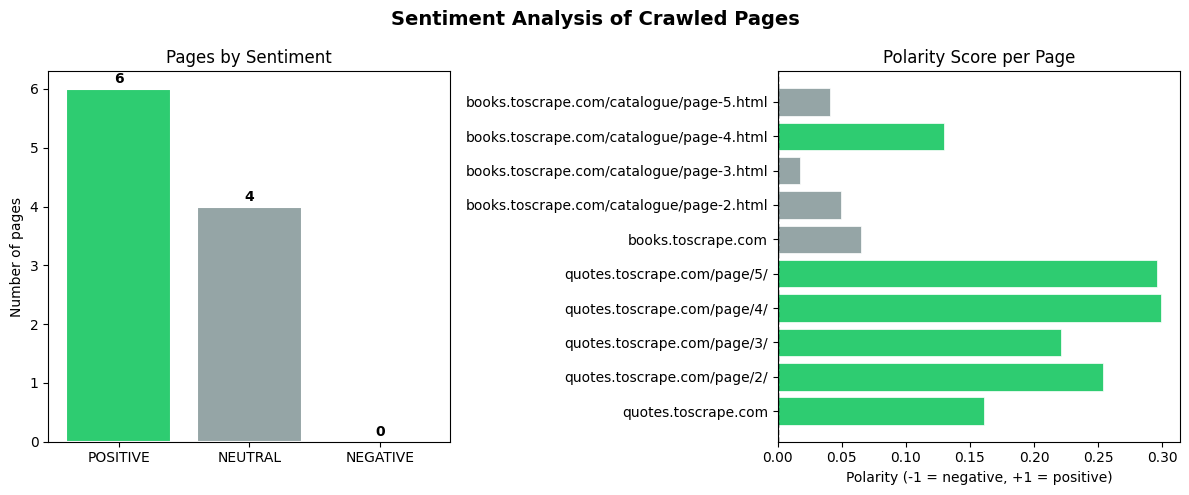

Sentiment chart saved to: /content/drive/MyDrive/distributed-crawler/plots/plot4_sentiment.png
Sentiment data saved to: /content/drive/MyDrive/distributed-crawler/data/sentiment_results.json


In [31]:
# Count how many pages are positive, negative, and neutral
from collections import Counter

# Count sentiments
sentiment_counts = Counter(r['sentiment'] for r in sentiment_results)

# Calculate the average polarity across all pages
avg_polarity = round(sum(r['polarity'] for r in sentiment_results) / len(sentiment_results), 3)

# Print summary statistics
print('Sentiment Summary:')
print(f'  POSITIVE pages : {sentiment_counts["POSITIVE"]}')
print(f'  NEUTRAL pages  : {sentiment_counts["NEUTRAL"]}')
print(f'  NEGATIVE pages : {sentiment_counts["NEGATIVE"]}')
print(f'  Average polarity: {avg_polarity} (range: -1.0 to +1.0)')

# Create a bar chart showing sentiment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Sentiment Analysis of Crawled Pages', fontsize=14, fontweight='bold')

# Left chart: sentiment count bar chart
labels  = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
values  = [sentiment_counts[l] for l in labels]
colors  = ['#2ecc71', '#95a5a6', '#e74c3c']
ax1.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Pages by Sentiment')
ax1.set_ylabel('Number of pages')
# Add count labels on top of each bar
for i, v in enumerate(values):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Right chart: polarity score for each URL
urls      = [r['url'].replace('https://', '')[:40] for r in sentiment_results]
polarities = [r['polarity'] for r in sentiment_results]
bar_colors = ['#2ecc71' if p > 0.1 else '#e74c3c' if p < -0.1 else '#95a5a6' for p in polarities]
ax2.barh(urls, polarities, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=1, linestyle='--')  # Zero line
ax2.set_title('Polarity Score per Page')
ax2.set_xlabel('Polarity (-1 = negative, +1 = positive)')

plt.tight_layout()

# Save the chart to Google Drive
sentiment_plot_path = f'{BASE}/plots/plot4_sentiment.png'
plt.savefig(sentiment_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sentiment chart saved to: {sentiment_plot_path}')

# Save full sentiment results to JSON
sentiment_json_path = f'{BASE}/data/sentiment_results.json'
with open(sentiment_json_path, 'w') as f:
    # Save only the fields we need (skip the full page text to keep file small)
    save_data = [{'url': r['url'], 'sentiment': r['sentiment'],
                  'polarity': r['polarity'], 'subjectivity': r['subjectivity']}
                 for r in sentiment_results]
    json.dump(save_data, f, indent=2)

print(f'Sentiment data saved to: {sentiment_json_path}')

---
# PART 11 — Email Alerts
---
**What it does:** Sends an automatic email when crawl is complete.
The email contains: pages crawled, top words, sentiment summary, and timestamp.

### Setup required:
1. A Gmail account
2. Enable **App Password** (not your real password):
   - Go to: myaccount.google.com → Security → 2-Step Verification → App passwords
   - Create an app password for 'Mail'
   - Copy the 16-character password
3. Fill in your email and app password in the cell below

In [70]:
# Import smtplib — Python's built-in library for sending emails
import smtplib

# Import email modules to format the email message
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage

# Import datetime to add timestamp to the email
from datetime import datetime

# ── Fill in your email details here ──────────────────────────────────────
SENDER_EMAIL   = 'kiransiddique406@gmail.com'       # Your Gmail address
SENDER_PASSWORD = 'thbu kayw nkte ymza'       # Your 16-char Gmail App Password
RECEIVER_EMAIL  = 'kiransiddique406@gmail.com'      # Where to send the alert (can be same)
# ─────────────────────────────────────────────────────────────────────────

print('Email module ready!')
print('Make sure to fill in your Gmail and App Password above before running the next cell.')

Email module ready!
Make sure to fill in your Gmail and App Password above before running the next cell.


In [33]:
# Load analysis results to include in the email
with open(f'{BASE}/data/analysis_results.json', 'r') as f:
    analysis = json.load(f)

# Load sentiment results to include in the email
with open(f'{BASE}/data/sentiment_results.json', 'r') as f:
    sentiment_data = json.load(f)

# Get current timestamp
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Build the top 10 words string for the email
top10_quotes = ', '.join([f"{w} ({c})" for w, c in analysis['quotes_top50'][:10]])
top10_books  = ', '.join([f"{w} ({c})" for w, c in analysis['books_top50'][:10]])

# Count sentiments for the summary
pos = sum(1 for r in sentiment_data if r['sentiment'] == 'POSITIVE')
neg = sum(1 for r in sentiment_data if r['sentiment'] == 'NEGATIVE')
neu = sum(1 for r in sentiment_data if r['sentiment'] == 'NEUTRAL')

# Build the HTML email body — this will look nice in Gmail
html_body = f"""
<html><body style="font-family: Arial, sans-serif; max-width: 600px; margin: auto;">

  <h2 style="color: #6c3483;">Distributed Web Crawler — Crawl Complete!</h2>
  <p style="color: #666;">Crawl finished at: <strong>{timestamp}</strong></p>

  <hr style="border: 1px solid #eee;">

  <h3 style="color: #2e4057;">Crawl Summary</h3>
  <table style="width:100%; border-collapse: collapse;">
    <tr style="background:#f4f4f4;">
      <td style="padding:8px; border:1px solid #ddd;">Pages Crawled</td>
      <td style="padding:8px; border:1px solid #ddd;"><strong>{len(sentiment_data)}</strong></td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #ddd;">Unique Words (Quotes site)</td>
      <td style="padding:8px; border:1px solid #ddd;"><strong>{analysis['total_unique_quotes']}</strong></td>
    </tr>
    <tr style="background:#f4f4f4;">
      <td style="padding:8px; border:1px solid #ddd;">Unique Words (Books site)</td>
      <td style="padding:8px; border:1px solid #ddd;"><strong>{analysis['total_unique_books']}</strong></td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #ddd;">Common Words</td>
      <td style="padding:8px; border:1px solid #ddd;"><strong>{len(analysis['common_words'])}</strong></td>
    </tr>
  </table>

  <h3 style="color: #2e4057;">Sentiment Summary</h3>
  <p>
    Positive pages: <strong style="color:green;">{pos}</strong> &nbsp;|
    Neutral pages: <strong style="color:gray;">{neu}</strong> &nbsp;|
    Negative pages: <strong style="color:red;">{neg}</strong>
  </p>

  <h3 style="color: #2e4057;">Top 10 Words — Quotes Site</h3>
  <p style="background:#f9f9f9; padding:10px; border-radius:5px;">{top10_quotes}</p>

  <h3 style="color: #2e4057;">Top 10 Words — Books Site</h3>
  <p style="background:#f9f9f9; padding:10px; border-radius:5px;">{top10_books}</p>

  <hr style="border: 1px solid #eee;">
  <p style="color:#aaa; font-size:12px;">Sent automatically by your Distributed Web Crawler project.</p>

</body></html>
"""

# Build the email message object
msg = MIMEMultipart('related')
msg['Subject'] = f'Crawler Alert — Crawl Complete at {timestamp}'
msg['From']    = SENDER_EMAIL
msg['To']      = RECEIVER_EMAIL

# Attach the HTML body to the email
msg.attach(MIMEText(html_body, 'html'))

# Attach the sentiment chart image if it exists
sentiment_plot = f'{BASE}/plots/plot4_sentiment.png'
if os.path.exists(sentiment_plot):
    with open(sentiment_plot, 'rb') as img_file:
        img = MIMEImage(img_file.read())
        img.add_header('Content-Disposition', 'attachment', filename='sentiment_chart.png')
        msg.attach(img)

# Send the email using Gmail SMTP server
try:
    # Connect to Gmail's SMTP server on port 587 (TLS)
    with smtplib.SMTP('smtp.gmail.com', 587) as server:
        server.starttls()                              # Start encrypted connection
        server.login(SENDER_EMAIL, SENDER_PASSWORD)    # Login with app password
        server.send_message(msg)                       # Send the email

    print('Email sent successfully!')
    print(f'  To      : {RECEIVER_EMAIL}')
    print(f'  Subject : Crawler Alert - Crawl Complete at {timestamp}')
    print(f'  Attached: sentiment chart')

except Exception as e:
    print(f'Email failed: {e}')
    print('Make sure your App Password is correct and 2-Step Verification is enabled.')

Email sent successfully!
  To      : sabagu003@gmail.com
  Subject : Crawler Alert - Crawl Complete at 2026-04-27 16:36:14
  Attached: sentiment chart


---
# PART 12 — Crawl History
---
**What it does:** Every time you run a crawl, the results are saved with a timestamp.
Later you can load all history and compare — did word frequencies change over time?

Run this part after every crawl to build up your history.

In [34]:
# Import datetime to record when each crawl happened
from datetime import datetime

# Import json and os for file operations
import json, os

# Define the path for the crawl history file
# All crawl sessions will be appended to this single file
HISTORY_FILE = f'{BASE}/data/crawl_history.json'

# Load existing history if the file already exists
# Otherwise start with an empty list
if os.path.exists(HISTORY_FILE):
    with open(HISTORY_FILE, 'r') as f:
        crawl_history = json.load(f)
    print(f'Loaded existing history: {len(crawl_history)} previous crawl(s) found.')
else:
    crawl_history = []
    print('No previous history found — starting fresh.')

print('History module ready!')

Loaded existing history: 1 previous crawl(s) found.
History module ready!


In [35]:
# Load current crawl's analysis results
with open(f'{BASE}/data/analysis_results.json', 'r') as f:
    analysis = json.load(f)

# Load current crawl's sentiment results
with open(f'{BASE}/data/sentiment_results.json', 'r') as f:
    sentiment_data = json.load(f)

# Build the history entry for this crawl session
# We save a snapshot of key statistics so we can compare later
history_entry = {
    # Timestamp — when this crawl happened
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),

    # How many unique words each site had
    'unique_words_quotes': analysis['total_unique_quotes'],
    'unique_words_books':  analysis['total_unique_books'],

    # How many words are common between both sites
    'common_words_count': len(analysis['common_words']),

    # Top 20 words from each site (word + count pairs)
    'top20_quotes': analysis['quotes_top50'][:20],
    'top20_books':  analysis['books_top50'][:20],

    # Sentiment breakdown for this crawl
    'sentiment_positive': sum(1 for r in sentiment_data if r['sentiment'] == 'POSITIVE'),
    'sentiment_neutral':  sum(1 for r in sentiment_data if r['sentiment'] == 'NEUTRAL'),
    'sentiment_negative': sum(1 for r in sentiment_data if r['sentiment'] == 'NEGATIVE'),

    # Average polarity score across all pages
    'avg_polarity': round(sum(r['polarity'] for r in sentiment_data) / len(sentiment_data), 3),

    # Total pages crawled this session
    'pages_crawled': len(sentiment_data)
}

# Append this session to the history list
crawl_history.append(history_entry)

# Save updated history back to the JSON file
with open(HISTORY_FILE, 'w') as f:
    json.dump(crawl_history, f, indent=2)

print(f'Crawl session saved to history!')
print(f'Total sessions recorded: {len(crawl_history)}')
print(f'History file: {HISTORY_FILE}')

Crawl session saved to history!
Total sessions recorded: 2
History file: /content/drive/MyDrive/distributed-crawler/data/crawl_history.json


Session Timestamp              Pages   Quotes Words   Books Words  Avg Polarity
1     2026-04-27 11:09:53    10      417            279          0.153
2     2026-04-27 16:36:16    10      417            279          0.153


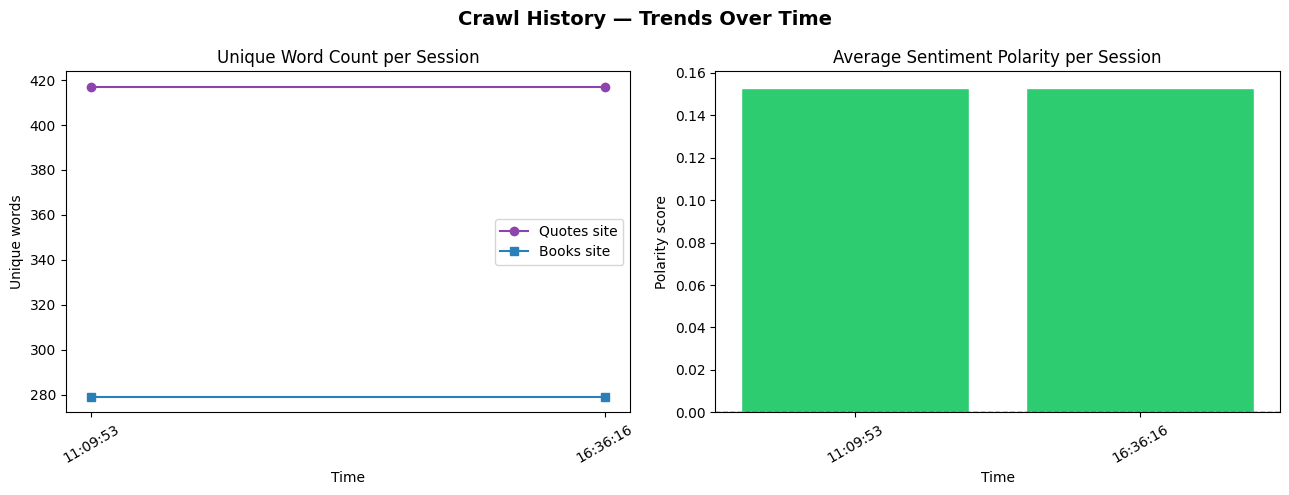

History chart saved: /content/drive/MyDrive/distributed-crawler/plots/plot5_history.png


In [36]:
# View and compare all crawl sessions
# This cell shows how your crawls have changed over time

import matplotlib.pyplot as plt

# Print a table of all history entries
print('=' * 75)
print(f'{"Session":<5} {"Timestamp":<22} {"Pages":<7} {"Quotes Words":<14} {"Books Words":<12} {"Avg Polarity"}')
print('=' * 75)
for i, entry in enumerate(crawl_history, 1):
    print(f"{i:<5} {entry['timestamp']:<22} {entry['pages_crawled']:<7} "
          f"{entry['unique_words_quotes']:<14} {entry['unique_words_books']:<12} "
          f"{entry['avg_polarity']}")
print('=' * 75)

# Only draw comparison chart if there are 2 or more sessions
if len(crawl_history) >= 2:
    # Extract data for the chart
    timestamps     = [e['timestamp'][-8:] for e in crawl_history]  # show only time
    quotes_words   = [e['unique_words_quotes'] for e in crawl_history]
    books_words    = [e['unique_words_books']  for e in crawl_history]
    avg_polarities = [e['avg_polarity']        for e in crawl_history]

    # Create side-by-side charts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Crawl History — Trends Over Time', fontsize=14, fontweight='bold')

    # Left chart: unique word count over sessions
    ax1.plot(timestamps, quotes_words, marker='o', label='Quotes site', color='#8e44ad')
    ax1.plot(timestamps, books_words,  marker='s', label='Books site',  color='#2980b9')
    ax1.set_title('Unique Word Count per Session')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Unique words')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=30)

    # Right chart: average sentiment polarity over sessions
    colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in avg_polarities]
    ax2.bar(timestamps, avg_polarities, color=colors, edgecolor='white')
    ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
    ax2.set_title('Average Sentiment Polarity per Session')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Polarity score')
    ax2.tick_params(axis='x', rotation=30)

    plt.tight_layout()

    # Save history comparison chart
    history_plot_path = f'{BASE}/plots/plot5_history.png'
    plt.savefig(history_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'History chart saved: {history_plot_path}')

else:
    # Not enough sessions yet for a trend chart
    print('Run the crawler again tomorrow to see trend comparison charts!')

---
# PART 14 — Recursive Crawler
---
**What it does:** Give it ONE starting URL — it automatically follows all links found on that page, then links on those pages, and so on.

- You control the **depth** (how many levels deep to follow links)
- You control the **max pages** limit (so it doesn't crawl the whole internet!)
- Uses BFS (Breadth-First Search) — visits pages level by level

> **Depth = 1** -> crawl only the start page
> **Depth = 2** -> crawl start page + all its links
> **Depth = 3** -> crawl start page + links + links of links

In [37]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import dask.bag as db
import json, os, re, time
from collections import deque

print('Recursive crawler libraries ready!')

Recursive crawler libraries ready!


In [38]:
# ── Configuration — change these values to control the crawl ─────────────
START_URL        = 'https://quotes.toscrape.com'  # Starting URL
MAX_DEPTH        = 2                              # How many levels deep to go
MAX_PAGES        = 20                              # Maximum total pages to crawl
SAME_DOMAIN_ONLY = True                            # Only follow links on same website
DELAY_SECONDS    = 0.5                             # Polite delay between requests

print(f'Recursive Crawler Settings:')
print(f'  Start URL       : {START_URL}')
print(f'  Max depth       : {MAX_DEPTH}')
print(f'  Max pages       : {MAX_PAGES}')
print(f'  Same domain only: {SAME_DOMAIN_ONLY}')

Recursive Crawler Settings:
  Start URL       : https://quotes.toscrape.com
  Max depth       : 2
  Max pages       : 20
  Same domain only: True


In [39]:
def extract_links(soup, base_url, same_domain_only=True):
    """Find all valid links on a page, optionally filtered to same domain."""
    base_domain = urlparse(base_url).netloc
    links = set()
    for a_tag in soup.find_all('a', href=True):
        href = a_tag['href'].strip()
        if not href or href.startswith(('#', 'javascript:', 'mailto:')):
            continue
        # Convert relative URL to absolute URL
        full_url = urljoin(base_url, href)
        if not full_url.startswith('http'):
            continue
        if same_domain_only:
            if urlparse(full_url).netloc != base_domain:
                continue
        links.add(full_url)
    return links


def fetch_page_recursive(url):
    """Crawl a single URL and return its text and outgoing links."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (compatible; ResearchBot/1.0)'}
        response = requests.get(url, timeout=10, headers=headers)
        if response.status_code != 200:
            return {'url': url, 'text': '', 'links': [], 'status': response.status_code}
        soup = BeautifulSoup(response.text, 'html.parser')
        for tag in soup(['script', 'style', 'nav', 'footer', 'head']):
            tag.decompose()
        text  = soup.get_text(separator=' ', strip=True)
        links = extract_links(soup, url, SAME_DOMAIN_ONLY)
        return {'url': url, 'text': text, 'links': list(links), 'status': 200}
    except Exception as e:
        return {'url': url, 'text': '', 'links': [], 'status': f'error: {e}'}


print('Recursive crawler functions defined!')

Recursive crawler functions defined!


In [40]:
# ── BFS Recursive Crawl ───────────────────────────────────────────────────
print(f'Starting recursive crawl from: {START_URL}')
print(f'Depth limit: {MAX_DEPTH} | Page limit: {MAX_PAGES}')
print('=' * 65)

# Queue: (url, current_depth)
queue   = deque([(START_URL, 0)])
visited = set()
recursive_results = []

while queue and len(recursive_results) < MAX_PAGES:
    url, depth = queue.popleft()

    if url in visited or depth > MAX_DEPTH:
        continue

    visited.add(url)

    print(f'  [Depth {depth}] Crawling: {url[:70]}')
    result = fetch_page_recursive(url)
    result['depth'] = depth

    if result['text']:
        recursive_results.append(result)

    # Add found links to queue at next depth level
    if depth < MAX_DEPTH:
        for link in result.get('links', []):
            if link not in visited:
                queue.append((link, depth + 1))

    time.sleep(DELAY_SECONDS)

print('=' * 65)
print(f'Recursive crawl complete!')
print(f'  Pages crawled    : {len(recursive_results)}')
print(f'  Unique URLs seen : {len(visited)}')

from collections import Counter
depth_counts = Counter(r['depth'] for r in recursive_results)
for d in sorted(depth_counts):
    print(f'  Depth {d}: {depth_counts[d]} pages')

Starting recursive crawl from: https://quotes.toscrape.com
Depth limit: 2 | Page limit: 20
  [Depth 0] Crawling: https://quotes.toscrape.com
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/inspirational/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/life/page/1/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/be-yourself/page/1/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/truth/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/simile/
  [Depth 1] Crawling: https://quotes.toscrape.com/author/Marilyn-Monroe
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/success/page/1/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/live/page/1/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/humor/
  [Depth 1] Crawling: https://quotes.toscrape.com/author/Steve-Martin
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/edison/page/1/
  [Depth 1] Crawling: https://quotes.toscrape.com/tag/deep-thoughts/page/1/
  [Depth 1] Crawling: https://quotes.tosc

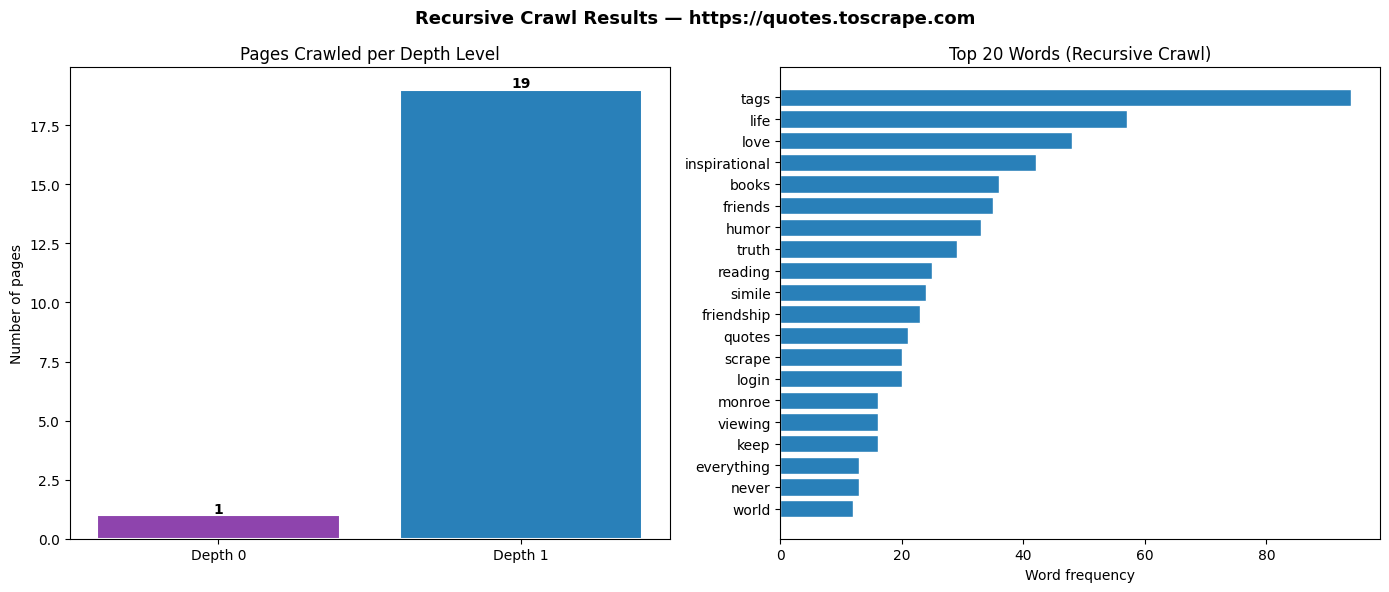

Recursive crawl chart saved: /content/drive/MyDrive/distributed-crawler/plots/plot7_recursive_crawl.png
Recursive crawl data saved: /content/drive/MyDrive/distributed-crawler/data/recursive_crawl.json


In [41]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords

STOP_REC = set(stopwords.words('english'))
STOP_REC.update(['would','could','also','one','two','get','got',
                 'us','may','even','well','like','much','many',
                 'page','next','prev','back','home','click'])

def clean_recursive(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [w for w in text.split() if w not in STOP_REC and len(w) > 3]

# Combine all text and count words
all_words_rec = []
for r in recursive_results:
    all_words_rec.extend(clean_recursive(r['text']))
top_words_rec = Counter(all_words_rec).most_common(20)

depth_counts = Counter(r['depth'] for r in recursive_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Recursive Crawl Results — {START_URL}', fontsize=13, fontweight='bold')

# Left: pages per depth
depths = sorted(depth_counts.keys())
counts = [depth_counts[d] for d in depths]
axes[0].bar([f'Depth {d}' for d in depths], counts,
            color=['#8e44ad','#2980b9','#27ae60','#e67e22'][:len(depths)],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Pages Crawled per Depth Level')
axes[0].set_ylabel('Number of pages')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Right: top 20 words
words_r  = [w for w, c in top_words_rec]
counts_r = [c for w, c in top_words_rec]
axes[1].barh(words_r[::-1], counts_r[::-1], color='#2980b9', edgecolor='white')
axes[1].set_title('Top 20 Words (Recursive Crawl)')
axes[1].set_xlabel('Word frequency')

plt.tight_layout()
plot_path_rec = f'{BASE}/plots/plot7_recursive_crawl.png'
plt.savefig(plot_path_rec, dpi=150, bbox_inches='tight')
plt.show()
print(f'Recursive crawl chart saved: {plot_path_rec}')

rec_save = [{'url': r['url'], 'depth': r['depth'],
             'text_length': len(r['text']), 'links_found': len(r['links'])}
            for r in recursive_results]
with open(f'{BASE}/data/recursive_crawl.json', 'w') as f:
    json.dump(rec_save, f, indent=2)
print(f'Recursive crawl data saved: {BASE}/data/recursive_crawl.json')

---
# PART 15 — TF-IDF Analysis
---
**What it does:** Finds which words are *uniquely important* to each website — not just the most frequent ones.

### Simple explanation:
- **TF (Term Frequency):** How often a word appears in one page
- **IDF (Inverse Document Frequency):** How rare is this word across ALL pages
- **TF-IDF Score = TF x IDF** — High score = word is important AND unique to this page

**Example:**
- "book" appears on every page -> low IDF -> low TF-IDF (not special)
- "melancholy" appears only on quotes pages -> high IDF -> high TF-IDF (very special!)

> Run Parts 1-3 first so crawled_data is available.

In [42]:
!pip install scikit-learn --quiet
print('scikit-learn installed!')

scikit-learn installed!


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)

quotes_pages = [r for r in crawled_data if 'quotes' in r['url']]
books_pages  = [r for r in crawled_data if 'books'  in r['url']]

quotes_text = ' '.join([r['text'] for r in quotes_pages])
books_text  = ' '.join([r['text'] for r in books_pages])

all_docs = [r['text'] for r in crawled_data]
all_urls = [r['url']  for r in crawled_data]

print(f'Quotes site: {len(quotes_pages)} pages, {len(quotes_text.split())} total words')
print(f'Books site : {len(books_pages)} pages, {len(books_text.split())} total words')

Quotes site: 5 pages, 1750 total words
Books site : 5 pages, 1633 total words


In [44]:
# TF-IDF vectorizer over all individual pages
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    min_df=1,
    ngram_range=(1, 2),
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(all_docs)
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=[url[-45:] for url in all_urls],
    columns=feature_names
)

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  Rows (pages) : {tfidf_matrix.shape[0]}')
print(f'  Columns (terms): {tfidf_matrix.shape[1]}')
print()

avg_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False)
print('Top 10 terms by average TF-IDF score:')
for term, score in avg_tfidf.head(10).items():
    print(f'  {term:<25} score: {score:.4f}')

TF-IDF matrix shape: (10, 500)
  Rows (pages) : 10
  Columns (terms): 500

Top 10 terms by average TF-IDF score:
  add                       score: 0.0988
  stock add                 score: 0.0976
  basket                    score: 0.0976
  add basket                score: 0.0976
  stock                     score: 0.0976
  tags                      score: 0.0973
  fiction                   score: 0.0682
  love                      score: 0.0657
  books                     score: 0.0627
  quotes                    score: 0.0608


In [45]:
# Site-level TF-IDF: treat each site as one document
site_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=200,
    ngram_range=(1, 2),
    sublinear_tf=True
)

site_docs   = [quotes_text, books_text]
site_labels = ['Quotes Site', 'Books Site']

site_matrix   = site_vectorizer.fit_transform(site_docs)
site_features = site_vectorizer.get_feature_names_out()
site_df = pd.DataFrame(
    site_matrix.toarray(),
    index=site_labels,
    columns=site_features
)

top_n = 20
quotes_top_tfidf = site_df.loc['Quotes Site'].sort_values(ascending=False).head(top_n)
books_top_tfidf  = site_df.loc['Books Site'].sort_values(ascending=False).head(top_n)

print('Top 20 TF-IDF Terms — Quotes Site:')
for term, score in quotes_top_tfidf.items():
    bar = chr(9608) * int(score * 200)
    print(f'  {term:<25} {score:.4f}  {bar}')

print()
print('Top 20 TF-IDF Terms — Books Site:')
for term, score in books_top_tfidf.items():
    bar = chr(9608) * int(score * 200)
    print(f'  {term:<25} {score:.4f}  {bar}')

Top 20 TF-IDF Terms — Quotes Site:
  tags                      0.2461  █████████████████████████████████████████████████
  quotes                    0.1836  ████████████████████████████████████
  inspirational             0.1802  ████████████████████████████████████
  friends                   0.1765  ███████████████████████████████████
  quotes scrape             0.1635  ████████████████████████████████
  reading                   0.1635  ████████████████████████████████
  tags love                 0.1583  ███████████████████████████████
  love                      0.1538  ██████████████████████████████
  einstein                  0.1525  ██████████████████████████████
  albert                    0.1525  ██████████████████████████████
  albert einstein           0.1525  ██████████████████████████████
  einstein tags             0.1525  ██████████████████████████████
  make                      0.1459  █████████████████████████████
  know                      0.1459  ██████████████████

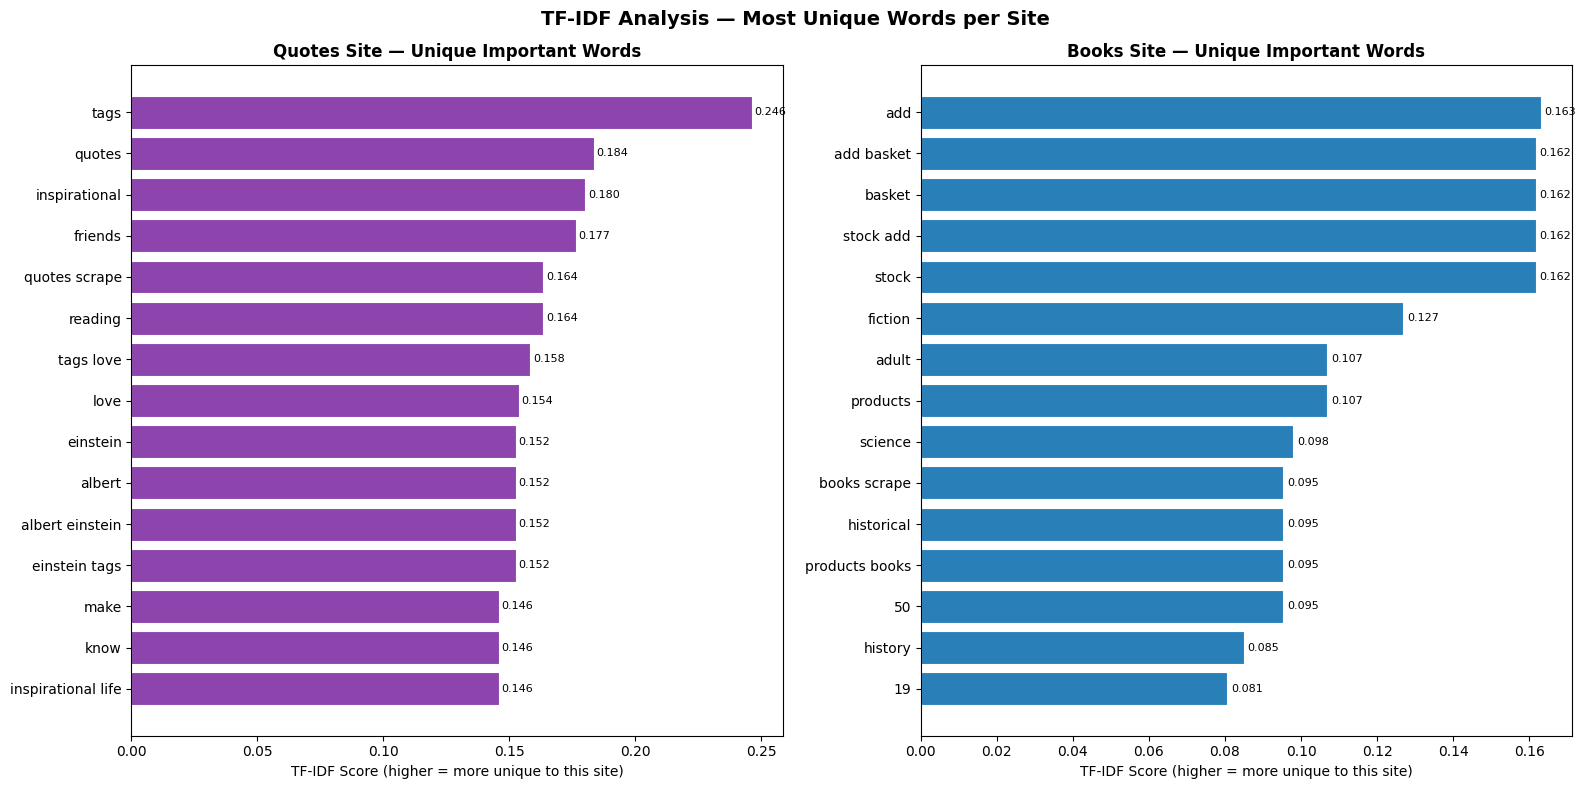

TF-IDF chart saved: /content/drive/MyDrive/distributed-crawler/plots/plot8_tfidf.png
TF-IDF data saved: /content/drive/MyDrive/distributed-crawler/data/tfidf_results.json


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('TF-IDF Analysis — Most Unique Words per Site', fontsize=14, fontweight='bold')

q_terms  = list(quotes_top_tfidf.index[:15])
q_scores = list(quotes_top_tfidf.values[:15])
axes[0].barh(q_terms[::-1], q_scores[::-1], color='#8e44ad', edgecolor='white', linewidth=0.8)
axes[0].set_title('Quotes Site — Unique Important Words', fontweight='bold')
axes[0].set_xlabel('TF-IDF Score (higher = more unique to this site)')
for i, (term, score) in enumerate(zip(q_terms[::-1], q_scores[::-1])):
    axes[0].text(score + 0.001, i, f'{score:.3f}', va='center', fontsize=8)

b_terms  = list(books_top_tfidf.index[:15])
b_scores = list(books_top_tfidf.values[:15])
axes[1].barh(b_terms[::-1], b_scores[::-1], color='#2980b9', edgecolor='white', linewidth=0.8)
axes[1].set_title('Books Site — Unique Important Words', fontweight='bold')
axes[1].set_xlabel('TF-IDF Score (higher = more unique to this site)')
for i, (term, score) in enumerate(zip(b_terms[::-1], b_scores[::-1])):
    axes[1].text(score + 0.001, i, f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
tfidf_plot_path = f'{BASE}/plots/plot8_tfidf.png'
plt.savefig(tfidf_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'TF-IDF chart saved: {tfidf_plot_path}')

tfidf_results = {
    'quotes_top20_tfidf': [(t, round(float(s), 4)) for t, s in quotes_top_tfidf.items()],
    'books_top20_tfidf':  [(t, round(float(s), 4)) for t, s in books_top_tfidf.items()],
}
with open(f'{BASE}/data/tfidf_results.json', 'w') as f:
    json.dump(tfidf_results, f, indent=2)
print(f'TF-IDF data saved: {BASE}/data/tfidf_results.json')

---
# PART 16 — Website Comparison Dashboard
---
**What it does:** Creates a complete 6-panel side-by-side comparison of two websites.

| Panel | What it shows |
|-------|--------------|
| 1 | Key metrics comparison (words, vocabulary, sentence length) |
| 2 | Vocabulary overlap — shared vs unique words |
| 3 | Reading level (Flesch score + grade level) |
| 4 | Top words side by side |
| 5 | Sentiment comparison |
| 6 | TF-IDF unique defining words |

> Parts 3, 10, and 15 must have run first (analysis_results.json, sentiment_results.json, tfidf_results.json needed).

In [48]:
!pip install textstat --quiet
print('textstat installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.9 MB/s eta 0:00:00
textstat installed!


In [49]:
import textstat
import json, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from collections import Counter
from nltk.corpus import stopwords

with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)
with open(f'{BASE}/data/analysis_results.json', 'r') as f:
    analysis = json.load(f)
with open(f'{BASE}/data/tfidf_results.json', 'r') as f:
    tfidf_data = json.load(f)
with open(f'{BASE}/data/sentiment_results.json', 'r') as f:
    sentiment_data = json.load(f)

quotes_pages = [r for r in crawled_data if 'quotes' in r['url']]
books_pages  = [r for r in crawled_data if 'books'  in r['url']]
quotes_text_combined = ' '.join([r['text'] for r in quotes_pages])
books_text_combined  = ' '.join([r['text'] for r in books_pages])

print('All data loaded for dashboard!')

All data loaded for dashboard!


In [50]:
STOP_DASH = set(stopwords.words('english'))
STOP_DASH.update(['would','could','also','one','two','get','got',
                  'us','may','even','well','like','much','many'])

def get_clean_words(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [w for w in text.split() if w not in STOP_DASH and len(w) > 2]

def avg_sentence_length(text):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    if not sentences:
        return 0
    return round(np.mean([len(s.split()) for s in sentences]), 1)

def flesch_label(score):
    if score >= 90: return 'Very Easy'
    if score >= 70: return 'Easy'
    if score >= 60: return 'Standard'
    if score >= 50: return 'Fairly Hard'
    if score >= 30: return 'Difficult'
    return 'Very Hard'

metrics = {}
for label, text, pages, sent_filter in [
    ('Quotes Site', quotes_text_combined, quotes_pages, 'quotes'),
    ('Books Site',  books_text_combined,  books_pages,  'books'),
]:
    clean_words = get_clean_words(text)
    word_counts = Counter(clean_words)
    vocab       = set(clean_words)
    site_sent   = [s for s in sentiment_data if sent_filter in s['url']]
    avg_pol     = round(np.mean([s['polarity'] for s in site_sent]), 3) if site_sent else 0
    pos_pct     = round(sum(1 for s in site_sent if s['sentiment'] == 'POSITIVE') /
                        max(len(site_sent), 1) * 100)
    metrics[label] = {
        'total_words':     len(clean_words),
        'unique_words':    len(vocab),
        'avg_word_length': round(np.mean([len(w) for w in clean_words]), 2),
        'avg_sent_length': avg_sentence_length(text),
        'flesch_score':    round(textstat.flesch_reading_ease(text[:50000]), 1),
        'flesch_grade':    round(textstat.flesch_kincaid_grade(text[:50000]), 1),
        'top20':           word_counts.most_common(20),
        'vocab_set':       vocab,
        'avg_polarity':    avg_pol,
        'positive_pct':    pos_pct,
        'pages_count':     len(pages),
    }

overlap = metrics['Quotes Site']['vocab_set'] & metrics['Books Site']['vocab_set']
overlap_pct_q = round(len(overlap) / max(len(metrics['Quotes Site']['vocab_set']), 1) * 100, 1)
overlap_pct_b = round(len(overlap) / max(len(metrics['Books Site']['vocab_set']), 1) * 100, 1)

print('=' * 65)
print(f'{"Metric":<30} {"Quotes Site":>15} {"Books Site":>15}')
print('=' * 65)
rows = [
    ('Pages crawled',    metrics['Quotes Site']['pages_count'],    metrics['Books Site']['pages_count']),
    ('Total words',      metrics['Quotes Site']['total_words'],     metrics['Books Site']['total_words']),
    ('Unique words',     metrics['Quotes Site']['unique_words'],    metrics['Books Site']['unique_words']),
    ('Avg word length',  metrics['Quotes Site']['avg_word_length'], metrics['Books Site']['avg_word_length']),
    ('Avg sentence len', metrics['Quotes Site']['avg_sent_length'], metrics['Books Site']['avg_sent_length']),
    ('Flesch score',     metrics['Quotes Site']['flesch_score'],    metrics['Books Site']['flesch_score']),
    ('Grade level',      metrics['Quotes Site']['flesch_grade'],    metrics['Books Site']['flesch_grade']),
    ('Avg polarity',     metrics['Quotes Site']['avg_polarity'],    metrics['Books Site']['avg_polarity']),
    ('% Positive pages', str(metrics['Quotes Site']['positive_pct'])+'%', str(metrics['Books Site']['positive_pct'])+'%'),
]
for name, q, b in rows:
    print(f'{name:<30} {str(q):>15} {str(b):>15}')
print('-' * 65)
print(f'{"Shared vocabulary":<30} {len(overlap):>15} words in common')
print(f'{"Overlap (% of Quotes)":<30} {overlap_pct_q:>14}%')
print(f'{"Overlap (% of Books)":<30} {overlap_pct_b:>14}%')
print('=' * 65)

Metric                             Quotes Site      Books Site
Pages crawled                                5               5
Total words                                879             993
Unique words                               417             279
Avg word length                           5.81            6.03
Avg sentence len                          17.9            13.0
Flesch score                              68.3            62.4
Grade level                                8.1             7.7
Avg polarity                             0.246            0.06
% Positive pages                          100%             20%
-----------------------------------------------------------------
Shared vocabulary                           38 words in common
Overlap (% of Quotes)                     9.1%
Overlap (% of Books)                     13.6%


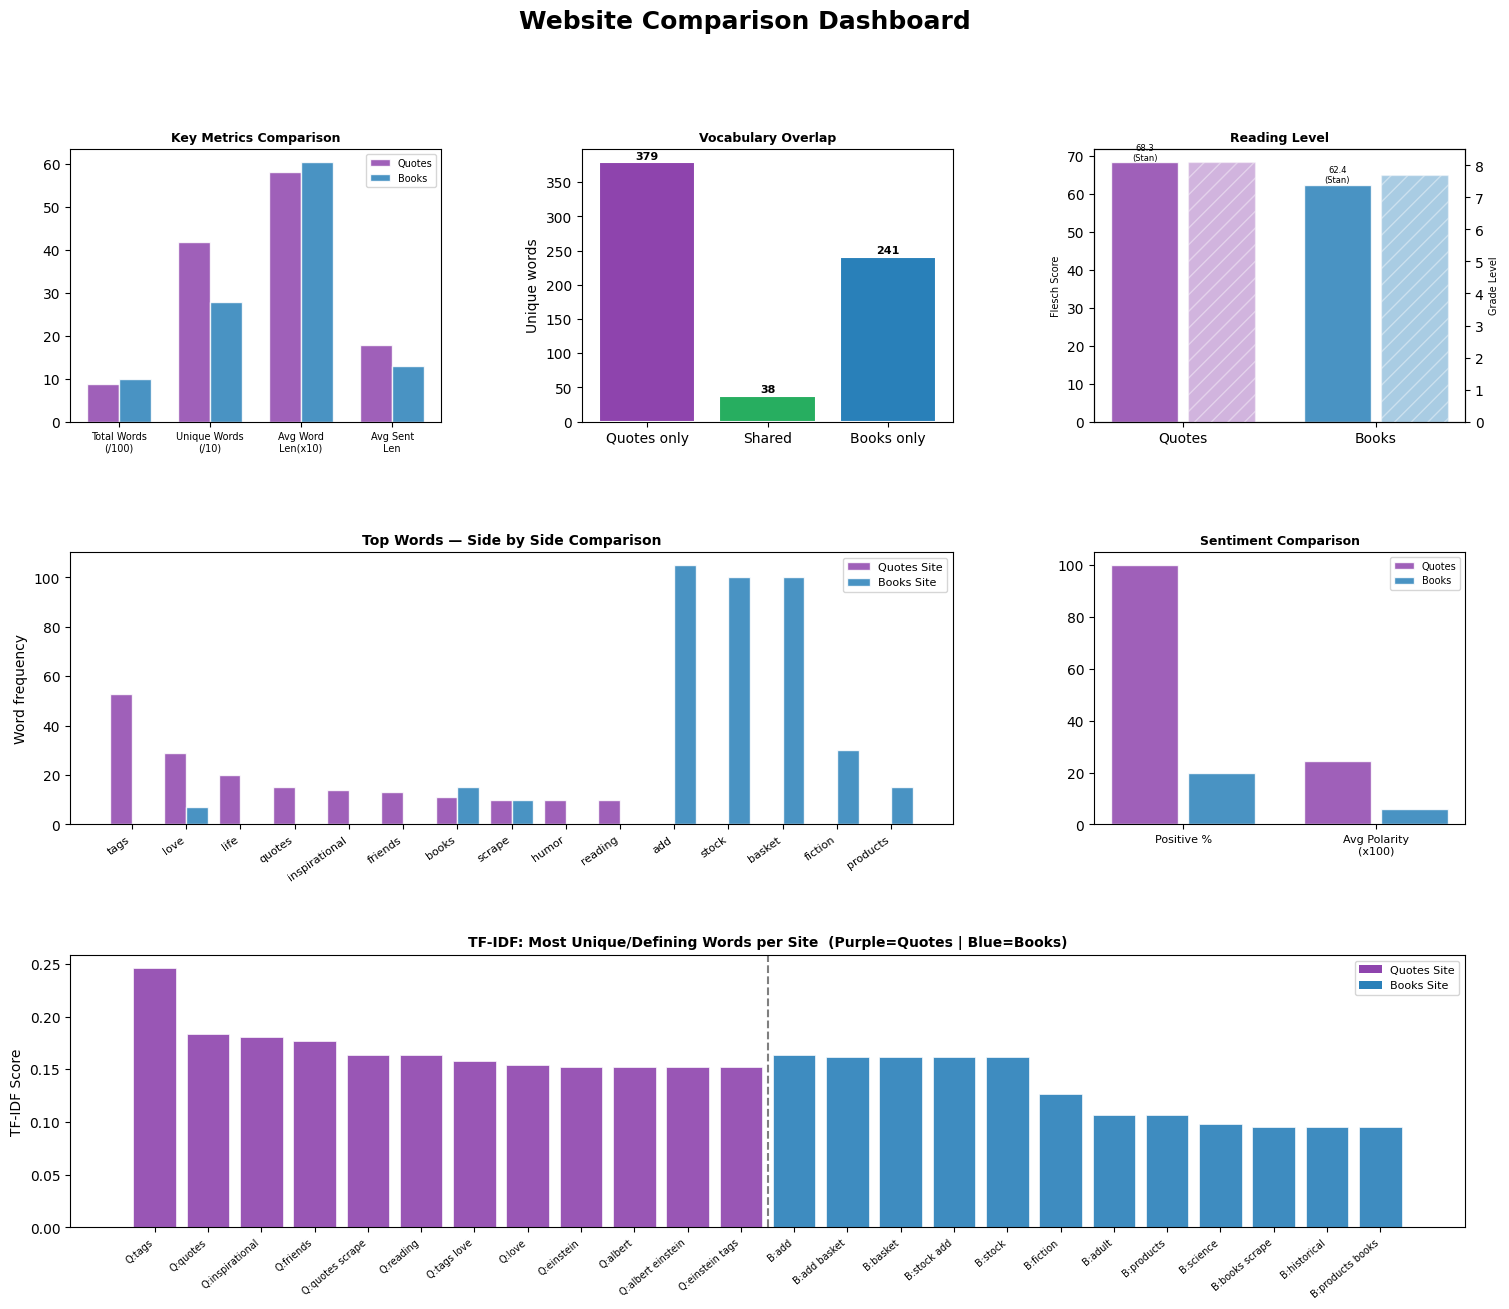

Comparison dashboard saved: /content/drive/MyDrive/distributed-crawler/plots/plot9_dashboard.png
Dashboard complete! 6 panels generated.


In [51]:
PURPLE = '#8e44ad'
BLUE   = '#2980b9'
GREEN  = '#27ae60'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Website Comparison Dashboard', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel 1 — Key metrics bar chart
ax1 = fig.add_subplot(gs[0, 0])
metric_names = ['Total Words\n(/100)', 'Unique Words\n(/10)', 'Avg Word\nLen(x10)', 'Avg Sent\nLen']
q_vals = [metrics['Quotes Site']['total_words']/100,
          metrics['Quotes Site']['unique_words']/10,
          metrics['Quotes Site']['avg_word_length']*10,
          metrics['Quotes Site']['avg_sent_length']]
b_vals = [metrics['Books Site']['total_words']/100,
          metrics['Books Site']['unique_words']/10,
          metrics['Books Site']['avg_word_length']*10,
          metrics['Books Site']['avg_sent_length']]
x = np.arange(len(metric_names)); w = 0.35
ax1.bar(x - w/2, q_vals, w, label='Quotes', color=PURPLE, alpha=0.85, edgecolor='white')
ax1.bar(x + w/2, b_vals, w, label='Books',  color=BLUE,   alpha=0.85, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(metric_names, fontsize=7)
ax1.set_title('Key Metrics Comparison', fontweight='bold', fontsize=9)
ax1.legend(fontsize=7)

# Panel 2 — Vocabulary overlap
ax2 = fig.add_subplot(gs[0, 1])
q_only = len(metrics['Quotes Site']['vocab_set'] - metrics['Books Site']['vocab_set'])
b_only = len(metrics['Books Site']['vocab_set']  - metrics['Quotes Site']['vocab_set'])
shared = len(overlap)
bars2 = ax2.bar(['Quotes only', 'Shared', 'Books only'], [q_only, shared, b_only],
                color=[PURPLE, GREEN, BLUE], edgecolor='white', linewidth=1.5)
ax2.set_title('Vocabulary Overlap', fontweight='bold', fontsize=9)
ax2.set_ylabel('Unique words')
for bar, val in zip(bars2, [q_only, shared, b_only]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=8, fontweight='bold')

# Panel 3 — Reading level
ax3 = fig.add_subplot(gs[0, 2])
ax3_twin = ax3.twinx()
x3 = np.arange(2)
flesch3 = [metrics['Quotes Site']['flesch_score'], metrics['Books Site']['flesch_score']]
grade3  = [metrics['Quotes Site']['flesch_grade'],  metrics['Books Site']['flesch_grade']]
b3a = ax3.bar(x3 - 0.2, flesch3, 0.35, color=[PURPLE, BLUE], alpha=0.85, edgecolor='white')
b3b = ax3_twin.bar(x3 + 0.2, grade3, 0.35, color=[PURPLE, BLUE], alpha=0.4, edgecolor='white', hatch='//')
ax3.set_xticks(x3); ax3.set_xticklabels(['Quotes', 'Books'])
ax3.set_ylabel('Flesch Score', fontsize=7); ax3_twin.set_ylabel('Grade Level', fontsize=7)
ax3.set_title('Reading Level', fontweight='bold', fontsize=9)
for bar, val in zip(b3a, flesch3):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val}\n({flesch_label(val)[:4]})', ha='center', fontsize=6)

# Panel 4 — Top words side by side (wide)
ax4 = fig.add_subplot(gs[1, :2])
q20 = dict(metrics['Quotes Site']['top20'][:15])
b20 = dict(metrics['Books Site']['top20'][:15])
top_w = list(dict.fromkeys(list(q20.keys())[:10] + list(b20.keys())[:10]))[:15]
q_bars4 = [q20.get(w, 0) for w in top_w]
b_bars4 = [b20.get(w, 0) for w in top_w]
x4 = np.arange(len(top_w)); w4 = 0.4
ax4.bar(x4 - w4/2, q_bars4, w4, label='Quotes Site', color=PURPLE, alpha=0.85, edgecolor='white')
ax4.bar(x4 + w4/2, b_bars4, w4, label='Books Site',  color=BLUE,   alpha=0.85, edgecolor='white')
ax4.set_xticks(x4); ax4.set_xticklabels(top_w, rotation=35, ha='right', fontsize=8)
ax4.set_title('Top Words — Side by Side Comparison', fontweight='bold', fontsize=10)
ax4.set_ylabel('Word frequency'); ax4.legend(fontsize=8)

# Panel 5 — Sentiment
ax5 = fig.add_subplot(gs[1, 2])
sent_labels = ['Positive %', 'Avg Polarity\n(x100)']
q_sent5 = [metrics['Quotes Site']['positive_pct'], metrics['Quotes Site']['avg_polarity']*100]
b_sent5 = [metrics['Books Site']['positive_pct'],  metrics['Books Site']['avg_polarity']*100]
x5 = np.arange(2)
ax5.bar(x5 - 0.2, q_sent5, 0.35, label='Quotes', color=PURPLE, alpha=0.85, edgecolor='white')
ax5.bar(x5 + 0.2, b_sent5, 0.35, label='Books',  color=BLUE,   alpha=0.85, edgecolor='white')
ax5.set_xticks(x5); ax5.set_xticklabels(sent_labels, fontsize=8)
ax5.set_title('Sentiment Comparison', fontweight='bold', fontsize=9)
ax5.legend(fontsize=7)

# Panel 6 — TF-IDF unique words (full width bottom)
ax6 = fig.add_subplot(gs[2, :])
q_tfidf_terms  = [t for t, s in tfidf_data['quotes_top20_tfidf'][:12]]
q_tfidf_scores = [s for t, s in tfidf_data['quotes_top20_tfidf'][:12]]
b_tfidf_terms  = [t for t, s in tfidf_data['books_top20_tfidf'][:12]]
b_tfidf_scores = [s for t, s in tfidf_data['books_top20_tfidf'][:12]]
combined_labels = [f'Q:{t}' for t in q_tfidf_terms] + [f'B:{t}' for t in b_tfidf_terms]
combined_scores = q_tfidf_scores + b_tfidf_scores
combined_colors = [PURPLE]*len(q_tfidf_terms) + [BLUE]*len(b_tfidf_terms)
x6 = np.arange(len(combined_labels))
ax6.bar(x6, combined_scores, color=combined_colors, edgecolor='white', linewidth=0.5, alpha=0.9)
ax6.set_xticks(x6); ax6.set_xticklabels(combined_labels, rotation=40, ha='right', fontsize=7)
ax6.set_title('TF-IDF: Most Unique/Defining Words per Site  (Purple=Quotes | Blue=Books)',
              fontweight='bold', fontsize=10)
ax6.set_ylabel('TF-IDF Score')
ax6.axvline(x=len(q_tfidf_terms)-0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
legend_patches = [Patch(facecolor=PURPLE, label='Quotes Site'),
                  Patch(facecolor=BLUE,   label='Books Site')]
ax6.legend(handles=legend_patches, fontsize=8, loc='upper right')

dashboard_path = f'{BASE}/plots/plot9_dashboard.png'
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Comparison dashboard saved: {dashboard_path}')
print('Dashboard complete! 6 panels generated.')

---
# PART 17 — Scheduled Crawling
---

## What is Scheduled Crawling?
Instead of running the crawler manually every time, **Scheduled Crawling** runs it **automatically** at fixed time intervals — every hour, every day, or every week.

This lets you **track trends over time**:
- Is a website talking more about "AI" this week than last week?
- Did a news site start using new keywords?
- Are certain words appearing more or less frequently?

## How it works in this notebook:
1. You set how often to crawl (interval in minutes)
2. The scheduler runs in the background inside Colab
3. Each crawl saves results with a timestamp
4. A trend chart is generated after each crawl showing change over time

> **Note:** This runs while the Colab tab is open. For true 24/7 scheduling, see the GitHub Actions tip at the bottom of this part.

In [52]:
# Install APScheduler — a simple Python job scheduling library
# It lets us run any function automatically at fixed time intervals
# For example: run crawl every 60 minutes without clicking anything
!pip install apscheduler --quiet

# Confirm installation
print("APScheduler installed successfully!")
print("This library lets us schedule functions to run automatically.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
APScheduler installed successfully!
This library lets us schedule functions to run automatically.


In [53]:
# Import the scheduling library
from apscheduler.schedulers.background import BackgroundScheduler

# Import all standard libraries we need
import requests                          # For sending HTTP requests to websites
from bs4 import BeautifulSoup            # For reading and parsing HTML pages
import dask.bag as db                    # For parallel processing with Dask
import json                              # For saving/loading data as JSON files
import os                                # For file and folder operations
import re                                # For cleaning text with regex patterns
import time                              # For adding delays between requests
from datetime import datetime            # For getting current date and time
from collections import Counter          # For counting word frequencies

# Import NLTK tools for removing common English words
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Import matplotlib for creating trend charts
import matplotlib.pyplot as plt
import matplotlib.dates as mdates        # For formatting date labels on charts

# ── Stop words setup ──────────────────────────────────────────────────────
# Build a set of words to ignore (like "the", "is", "a")
SCHED_STOP_WORDS = set(stopwords.words('english'))
SCHED_STOP_WORDS.update([
    'would', 'could', 'also', 'one', 'two', 'get', 'got',
    'us', 'may', 'even', 'well', 'like', 'much', 'many',
    'page', 'next', 'prev', 'back', 'home', 'click', 'site'
])

print("All imports successful!")
print("Scheduler and analysis libraries are ready.")

All imports successful!
Scheduler and analysis libraries are ready.


In [54]:
# ── Configuration — change these values to customize your schedule ────────

# List of websites to crawl automatically on each scheduled run
SCHEDULED_URLS = [
    'https://quotes.toscrape.com',    # Quotes practice website
    'https://books.toscrape.com',     # Books practice website
]

# How many pages to crawl from each website on each run
PAGES_PER_SITE = 3

# How many top words to track in the trend analysis
TOP_N_WORDS = 20

# How often to run the crawl (in minutes)
# Examples: 1 = every minute (for testing), 60 = every hour, 1440 = every day
CRAWL_INTERVAL_MINUTES = 2   # Set to 2 minutes so you can see it working quickly

# File where all scheduled crawl results will be saved
SCHEDULE_HISTORY_FILE = f'{BASE}/data/scheduled_history.json'

# Print the current configuration for the user to review
print("Scheduled Crawling Configuration:")
print(f"  URLs to crawl    : {SCHEDULED_URLS}")
print(f"  Pages per site   : {PAGES_PER_SITE}")
print(f"  Top words tracked: {TOP_N_WORDS}")
print(f"  Crawl interval   : every {CRAWL_INTERVAL_MINUTES} minute(s)")
print(f"  History file     : {SCHEDULE_HISTORY_FILE}")

Scheduled Crawling Configuration:
  URLs to crawl    : ['https://quotes.toscrape.com', 'https://books.toscrape.com']
  Pages per site   : 3
  Top words tracked: 20
  Crawl interval   : every 2 minute(s)
  History file     : /content/drive/MyDrive/distributed-crawler/data/scheduled_history.json


In [55]:
# ── Helper function: fetch one URL and return its text ────────────────────
def scheduled_fetch(url):
    """
    Visit a single URL and return all text from the page.
    Returns empty text if the page fails to load.
    """
    try:
        # Use a browser-like header so websites don't block our bot
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

        # Send HTTP GET request with a 10-second timeout limit
        response = requests.get(url, timeout=10, headers=headers)

        # Parse the HTML response with BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove tags that don't contain useful text
        for tag in soup(['script', 'style', 'nav', 'footer']):
            tag.decompose()

        # Extract all visible text from the page
        text = soup.get_text(separator=' ', strip=True)

        # Return success result
        return {'url': url, 'text': text, 'status': response.status_code}

    except Exception as e:
        # If something goes wrong, return empty result instead of crashing
        print(f"    Warning: Could not fetch {url} — {str(e)}")
        return {'url': url, 'text': '', 'status': 'error'}


# ── Helper function: clean text and count word frequencies ────────────────
def count_words(text):
    """
    Clean raw text and return a dictionary of word -> count.
    Removes stop words, numbers, and very short words.
    """
    # Step 1: Make everything lowercase for consistent counting
    text = text.lower()

    # Step 2: Remove everything that's not a letter or space
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 3: Split into individual words
    words = text.split()

    # Step 4: Keep only meaningful words (not stop words, length > 3)
    clean_words = [w for w in words if w not in SCHED_STOP_WORDS and len(w) > 3]

    # Step 5: Count how many times each word appears
    return dict(Counter(clean_words).most_common(TOP_N_WORDS))


print("Helper functions defined!")
print("  - scheduled_fetch() : visits a URL and returns its text")
print("  - count_words()     : cleans text and counts word frequencies")

Helper functions defined!
  - scheduled_fetch() : visits a URL and returns its text
  - count_words()     : cleans text and counts word frequencies


In [56]:
# ── Main scheduled job function ───────────────────────────────────────────
def run_scheduled_crawl():
    """
    This function runs automatically on every scheduled interval.
    It crawls all configured URLs, counts words, and saves results.
    """
    # Get the current timestamp for this crawl session
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    # Print separator and start message (newline stored in variable to avoid f-string error)
    print("\n" + "="*55)
    print(f"[SCHEDULER] Auto-crawl started at {timestamp}")
    print("="*55)

    # Step 1: Build the list of pages to crawl
    # We take PAGES_PER_SITE pages from each configured URL
    all_urls = []
    for base_url in SCHEDULED_URLS:
        all_urls.append(base_url)  # Add the main page
        base = base_url.rstrip('/')
        # Add extra pages using common pagination patterns
        for i in range(2, PAGES_PER_SITE + 1):
            if 'toscrape' in base:
                all_urls.append(f"{base}/page/{i}/")
            else:
                all_urls.append(f"{base}/?page={i}")

    print(f"[SCHEDULER] Crawling {len(all_urls)} pages using Dask parallel processing...")

    # Step 2: Use Dask to crawl all URLs at the same time (in parallel)
    url_bag = db.from_sequence(all_urls, npartitions=min(len(all_urls), 4))
    crawled  = url_bag.map(scheduled_fetch).compute()

    # Step 3: Combine all text from successful pages
    all_text = ' '.join([r['text'] for r in crawled if r['status'] == 200])

    # Step 4: Count word frequencies
    word_counts = count_words(all_text)

    # Step 5: Build the result entry for this crawl session
    crawl_entry = {
        'timestamp'    : timestamp,          # When this crawl happened
        'pages_crawled': len([r for r in crawled if r['status'] == 200]),
        'total_words'  : sum(word_counts.values()),
        'unique_words' : len(word_counts),
        'top_words'    : list(word_counts.items()),  # List of (word, count) pairs
        'urls_crawled' : [r['url'] for r in crawled if r['status'] == 200]
    }

    # Step 6: Load existing history (or start fresh if no history yet)
    if os.path.exists(SCHEDULE_HISTORY_FILE):
        with open(SCHEDULE_HISTORY_FILE, 'r') as f:
            history = json.load(f)
    else:
        history = []

    # Step 7: Add this crawl session to the history list
    history.append(crawl_entry)

    # Step 8: Save updated history back to JSON file
    with open(SCHEDULE_HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)

    # Step 9: Print summary of this crawl
    print(f"[SCHEDULER] Done! Pages: {crawl_entry['pages_crawled']} | "
          f"Words: {crawl_entry['total_words']} | Unique: {crawl_entry['unique_words']}")
    print(f"[SCHEDULER] Top 5 words: {list(word_counts.keys())[:5]}")
    print(f"[SCHEDULER] History saved — total sessions: {len(history)}")


# ── Test: run one crawl immediately before starting the scheduler ─────────
print("Running a test crawl to make sure everything works...")
run_scheduled_crawl()
print("\nTest crawl complete!")  # Fixed: newline outside f-string

Running a test crawl to make sure everything works...

[SCHEDULER] Auto-crawl started at 2026-04-27 16:42:06
[SCHEDULER] Crawling 6 pages using Dask parallel processing...
[SCHEDULER] Done! Pages: 4 | Words: 207 | Unique: 20
[SCHEDULER] Top 5 words: ['tags', 'stock', 'basket', 'love', 'life']
[SCHEDULER] History saved — total sessions: 103

Test crawl complete!


In [57]:
# ── Start the automatic scheduler ─────────────────────────────────────────
# BackgroundScheduler runs in a separate thread so it doesn't block this cell
scheduler = BackgroundScheduler()

# Add our crawl job to the scheduler
# 'interval' type means: run every X minutes
# minutes=CRAWL_INTERVAL_MINUTES is how often to run it
scheduler.add_job(
    func=run_scheduled_crawl,           # The function to call
    trigger='interval',                 # Run at regular intervals
    minutes=CRAWL_INTERVAL_MINUTES,     # How often (in minutes)
    id='web_crawler_job',               # A name for this job
    name='Distributed Web Crawler',     # Human-readable name
    replace_existing=True               # Replace if already exists
)

# Start the scheduler running in the background
scheduler.start()

# Calculate and show the next run time
from datetime import datetime, timedelta
next_run = datetime.now() + timedelta(minutes=CRAWL_INTERVAL_MINUTES)

print("=" * 55)
print("AUTO-SCHEDULER IS RUNNING!")
print("=" * 55)
print(f"  Crawl interval : every {CRAWL_INTERVAL_MINUTES} minute(s)")
print(f"  Next crawl at  : {next_run.strftime('%H:%M:%S')}")
print(f"  History file   : {SCHEDULE_HISTORY_FILE}")
print()
print("The crawler will run automatically in the background.")
print("You can run the NEXT cell to see live history + trend charts.")
print("To stop scheduling, run: scheduler.shutdown()")
print("=" * 55)

AUTO-SCHEDULER IS RUNNING!
  Crawl interval : every 2 minute(s)
  Next crawl at  : 16:44:37
  History file   : /content/drive/MyDrive/distributed-crawler/data/scheduled_history.json

The crawler will run automatically in the background.
You can run the NEXT cell to see live history + trend charts.
To stop scheduling, run: scheduler.shutdown()


  Scheduled Crawl History — 103 session(s) recorded
#    Timestamp              Pages   Total Words   Unique
----------------------------------------------------------------------
1    2026-04-27 11:10:05    4       207           20
2    2026-04-27 11:10:55    4       207           20
3    2026-04-27 11:12:05    4       207           20
4    2026-04-27 11:12:57    4       207           20
5    2026-04-27 11:14:05    4       207           20
6    2026-04-27 11:14:57    4       207           20
7    2026-04-27 11:16:05    4       207           20
8    2026-04-27 11:16:57    4       207           20
9    2026-04-27 11:18:05    4       207           20
10   2026-04-27 11:18:57    4       207           20
11   2026-04-27 11:20:05    4       207           20
12   2026-04-27 11:20:57    4       207           20
13   2026-04-27 11:22:05    4       207           20
14   2026-04-27 11:22:57    4       207           20
15   2026-04-27 11:24:05    4       207           20
16   2026-04-27 11:24:57 

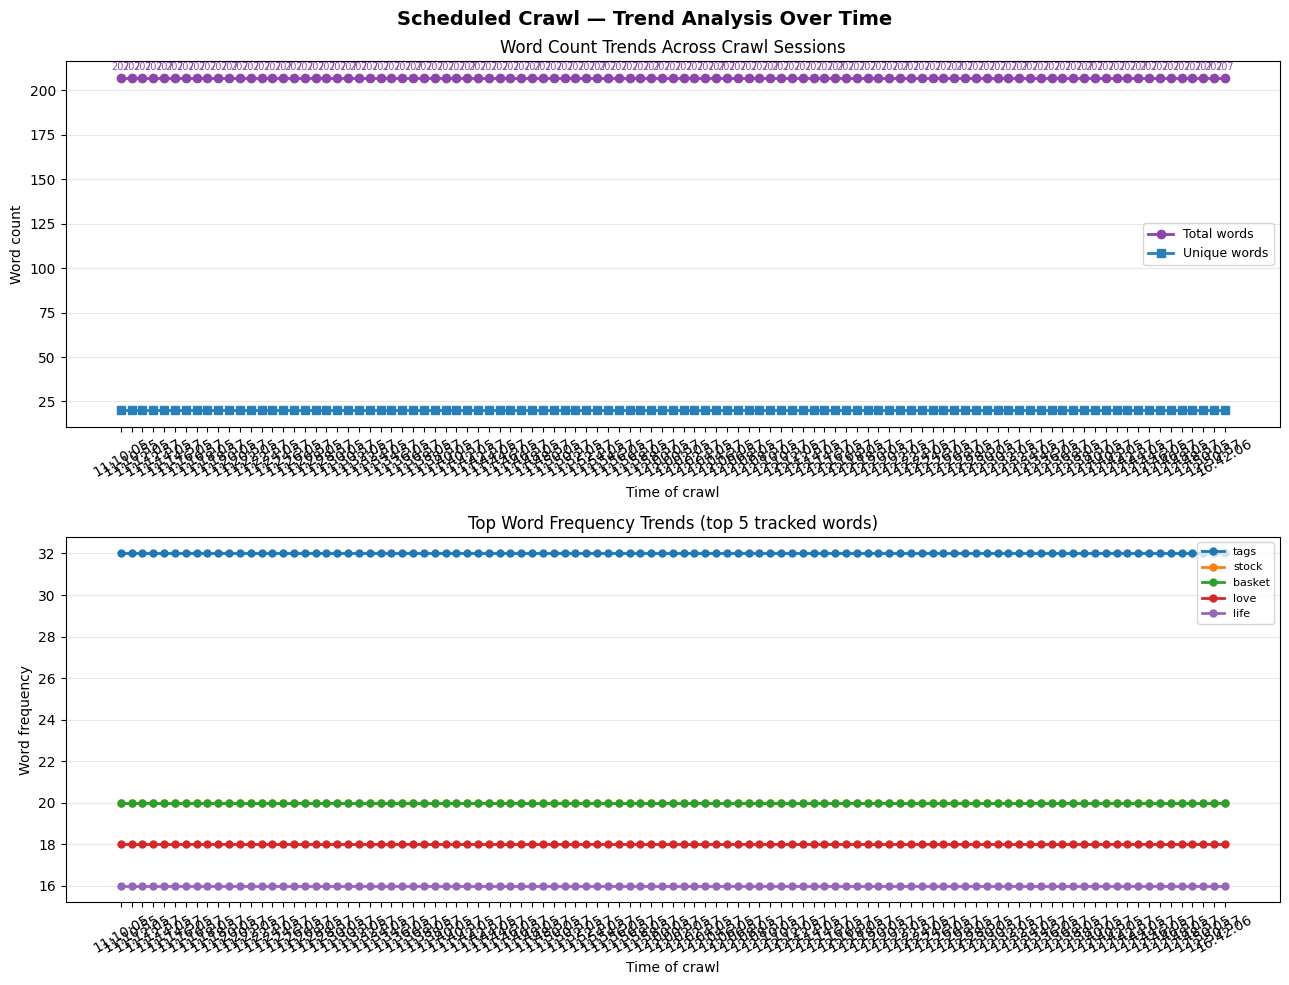


Trend chart saved: /content/drive/MyDrive/distributed-crawler/plots/plot10_schedule_trends.png


In [58]:
# ── View scheduled crawl history and trend charts ─────────────────────────
# Run this cell any time to see how the crawl results are changing over time

# Load the crawl history from Google Drive
if not os.path.exists(SCHEDULE_HISTORY_FILE):
    print("No history yet — wait for the first scheduled crawl to complete.")
else:
    with open(SCHEDULE_HISTORY_FILE, 'r') as f:
        history = json.load(f)

    # Print a table showing all crawl sessions so far
    print("=" * 70)
    print(f"  Scheduled Crawl History — {len(history)} session(s) recorded")
    print("=" * 70)
    print(f"{'#':<4} {'Timestamp':<22} {'Pages':<7} {'Total Words':<13} {'Unique'}")
    print("-" * 70)
    for i, entry in enumerate(history, 1):
        print(f"{i:<4} {entry['timestamp']:<22} {entry['pages_crawled']:<7} "
              f"{entry['total_words']:<13} {entry['unique_words']}")
    print("=" * 70)

    # Only draw trend charts if we have at least 2 sessions to compare
    if len(history) >= 2:

        # Extract data arrays for the charts
        timestamps   = [e['timestamp'][-8:] for e in history]  # Show HH:MM:SS only
        total_words  = [e['total_words']    for e in history]
        unique_words = [e['unique_words']   for e in history]

        # Track top 5 words across all sessions to show their trends
        all_word_names = []
        for entry in history:
            all_word_names.extend([w for w, c in entry['top_words'][:5]])
        top_tracked = [w for w, _ in Counter(all_word_names).most_common(5)]

        # Create the trend chart figure with 2 panels
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))
        fig.suptitle('Scheduled Crawl — Trend Analysis Over Time',
                     fontsize=14, fontweight='bold')

        # ── Top panel: total vs unique word count over sessions ───────────
        ax1.plot(timestamps, total_words,  marker='o', color='#8e44ad',
                 linewidth=2, markersize=6, label='Total words')
        ax1.plot(timestamps, unique_words, marker='s', color='#2980b9',
                 linewidth=2, markersize=6, label='Unique words')
        ax1.set_title('Word Count Trends Across Crawl Sessions')
        ax1.set_xlabel('Time of crawl')
        ax1.set_ylabel('Word count')
        ax1.legend(fontsize=9)
        ax1.tick_params(axis='x', rotation=30)
        ax1.grid(axis='y', alpha=0.3)

        # Add data labels on each point
        for x, y in zip(timestamps, total_words):
            ax1.annotate(str(y), (x, y), textcoords="offset points",
                         xytext=(0, 6), ha='center', fontsize=7, color='#8e44ad')

        # ── Bottom panel: frequency trend of top tracked words ─────────────
        for word in top_tracked:
            # Get this word's count in each session (0 if not in top words)
            word_trend = []
            for entry in history:
                word_dict = dict(entry['top_words'])
                word_trend.append(word_dict.get(word, 0))
            ax2.plot(timestamps, word_trend, marker='o', linewidth=2,
                     markersize=5, label=word)

        ax2.set_title('Top Word Frequency Trends (top 5 tracked words)')
        ax2.set_xlabel('Time of crawl')
        ax2.set_ylabel('Word frequency')
        ax2.legend(fontsize=8, loc='upper right')
        ax2.tick_params(axis='x', rotation=30)
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()

        # Save the trend chart to Google Drive
        trend_path = f'{BASE}/plots/plot10_schedule_trends.png'
        plt.savefig(trend_path, dpi=150, bbox_inches='tight')
        plt.show()

        # Fixed: newline outside f-string
        print("\nTrend chart saved: " + trend_path)

    else:
        # Fixed: newline outside f-string
        print("\nRun this cell again after the next scheduled crawl to see trend charts.")
        print(f"Next crawl in approximately {CRAWL_INTERVAL_MINUTES} minute(s).")

---
# PART 18 — Mini Search Engine (Search Crawled Pages)
---

## What is this?
After crawling websites, all the page text is saved. This part **indexes all that text** and lets you **search through it** — just like Google, but for your crawled data!

## How it works:
1. **Indexing phase:** For every word in every crawled page, we record which page(s) it appears on and how many times
2. **Search phase:** You type a word or phrase → the engine finds all pages containing it → ranks them by relevance
3. **Ranking:** Pages with more matches appear first (TF-IDF style scoring)

## What you can do:
- Search for a single word: `love`
- Search for a phrase: `great expectations`
- Search for an author name: `einstein`
- See which page had the most mentions of your query

In [59]:
# Import all libraries needed for the search engine
import json                      # For loading crawled data from JSON files
import re                        # For text cleaning with regular expressions
import os                        # For file path operations
import math                      # For logarithm used in IDF calculation
from collections import defaultdict, Counter  # For building the index efficiently

# Import NLTK stop words to skip common words during indexing
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Build the stop words set
SEARCH_STOP_WORDS = set(stopwords.words('english'))
SEARCH_STOP_WORDS.update([
    'would', 'could', 'also', 'one', 'two', 'get', 'got',
    'us', 'may', 'even', 'well', 'like', 'much', 'many'
])

print("Search engine libraries loaded!")
print("Ready to build the search index.")

Search engine libraries loaded!
Ready to build the search index.


In [60]:
# ── Step 1: Load all crawled page data from Google Drive ─────────────────
# This loads the data saved by the crawler in Part 2
with open(f'{BASE}/data/crawled_data.json', 'r', encoding='utf-8') as f:
    crawled_data = json.load(f)

# Filter out any pages that have no text (failed crawls)
crawled_data = [p for p in crawled_data if p.get('text', '').strip()]

print(f"Loaded {len(crawled_data)} crawled pages for indexing.")

# Show a preview of what pages we have
print("\nPages available to search:")  # Fixed: \n inside quotes, not a real newline
for i, page in enumerate(crawled_data):
    word_estimate = len(page['text'].split())
    print(f"  [{i}] {page['url'][:60]:<62} (~{word_estimate} words)")

Loaded 10 crawled pages for indexing.

Pages available to search:
  [0] https://quotes.toscrape.com                                    (~282 words)
  [1] https://quotes.toscrape.com/page/2/                            (~613 words)
  [2] https://quotes.toscrape.com/page/3/                            (~338 words)
  [3] https://quotes.toscrape.com/page/4/                            (~248 words)
  [4] https://quotes.toscrape.com/page/5/                            (~269 words)
  [5] https://books.toscrape.com                                     (~317 words)
  [6] https://books.toscrape.com/catalogue/page-2.html               (~324 words)
  [7] https://books.toscrape.com/catalogue/page-3.html               (~328 words)
  [8] https://books.toscrape.com/catalogue/page-4.html               (~334 words)
  [9] https://books.toscrape.com/catalogue/page-5.html               (~330 words)


In [61]:
# ── Step 2: Build the Inverted Index ─────────────────────────────────────
# An inverted index maps each WORD to a list of PAGES that contain it.
# This is exactly how Google's index works internally!
#
# Structure:
#   index = {
#       "word1": [(page_id, count, url), (page_id, count, url), ...],
#       "word2": [(page_id, count, url), ...],
#       ...
#   }

def clean_for_index(text):
    """
    Clean text for indexing.
    Returns a list of lowercase meaningful words.
    """
    text = text.lower()                          # Lowercase everything
    text = re.sub(r'[^a-z\s]', ' ', text)       # Keep only letters and spaces
    words = text.split()                          # Split into individual words
    # Remove stop words and very short words
    return [w for w in words if w not in SEARCH_STOP_WORDS and len(w) > 2]


# The main index: word -> list of (page_id, term_frequency, url)
inverted_index = defaultdict(list)

# Also store each page's full word count for TF-IDF scoring
page_word_counts = {}

print("Building inverted index...")

# Loop through every crawled page
for page_id, page in enumerate(crawled_data):
    text = page.get('text', '')

    # Clean the text and get word list
    words = clean_for_index(text)

    # Count how many times each word appears on this page
    word_freq = Counter(words)

    # Store the word count for this page (used in TF scoring)
    page_word_counts[page_id] = {
        'total_words': len(words),          # Total words on this page
        'url': page['url'],                 # Page URL
        'word_freq': dict(word_freq)        # Word frequencies
    }

    # Add each word to the inverted index
    for word, count in word_freq.items():
        inverted_index[word].append({
            'page_id': page_id,             # Which page contains this word
            'count': count,                  # How many times it appears
            'url': page['url']               # The URL of this page
        })

    print(f"  Indexed page {page_id}: {page['url'][:55]} ({len(word_freq)} unique terms)")

# Fixed: \n outside f-string
print("\nIndex built!")
print(f"  Total pages indexed  : {len(crawled_data)}")
print(f"  Total unique terms   : {len(inverted_index)}")
print(f"  Total index entries  : {sum(len(v) for v in inverted_index.values())}")

Building inverted index...
  Indexed page 0: https://quotes.toscrape.com (106 unique terms)
  Indexed page 1: https://quotes.toscrape.com/page/2/ (178 unique terms)
  Indexed page 2: https://quotes.toscrape.com/page/3/ (119 unique terms)
  Indexed page 3: https://quotes.toscrape.com/page/4/ (89 unique terms)
  Indexed page 4: https://quotes.toscrape.com/page/5/ (102 unique terms)
  Indexed page 5: https://books.toscrape.com (114 unique terms)
  Indexed page 6: https://books.toscrape.com/catalogue/page-2.html (119 unique terms)
  Indexed page 7: https://books.toscrape.com/catalogue/page-3.html (123 unique terms)
  Indexed page 8: https://books.toscrape.com/catalogue/page-4.html (122 unique terms)
  Indexed page 9: https://books.toscrape.com/catalogue/page-5.html (125 unique terms)

Index built!
  Total pages indexed  : 10
  Total unique terms   : 658
  Total index entries  : 1197


In [62]:
# ── Step 3: The Search Function ───────────────────────────────────────────
# This function takes a query string and returns ranked results

def search(query, top_k=5):
    """
    Search the crawled pages for a query.

    Parameters:
        query  : The search term (word or phrase)
        top_k  : How many results to return (default: 5)

    Returns:
        List of result dictionaries, ranked by relevance score.
    """
    # Clean the query the same way we cleaned the index
    query_words = clean_for_index(query)

    # Handle case where all query words were stop words
    if not query_words:
        print(f"Query '{query}' contains only stop words. Try a more specific search term.")
        return []

    # Fixed: \n outside f-string
    print(f"\nSearching for: '{query}'")
    print(f"Query terms after cleaning: {query_words}")
    print("-" * 60)

    # ── Score each page using TF-IDF-style scoring ─────────────────────────
    # For each query word, find all pages that contain it and add to scores
    page_scores = defaultdict(float)      # Score accumulator per page
    total_docs = len(crawled_data)        # Total number of documents (pages)

    for query_word in query_words:
        if query_word not in inverted_index:
            print(f"  Term '{query_word}' not found in any crawled page.")
            continue

        # Retrieve pages that contain this query word
        matching_pages = inverted_index[query_word]

        # IDF = log(total_docs / docs_containing_word)
        # Rare words get higher IDF score (they are more distinctive)
        idf = math.log(total_docs / len(matching_pages) + 1)

        # Score each matching page
        for match in matching_pages:
            page_id = match['page_id']
            count   = match['count']

            # TF = word count on this page / total words on this page
            total_words = page_word_counts[page_id]['total_words']
            tf = count / max(total_words, 1)

            # TF-IDF score for this word on this page
            tfidf_score = tf * idf

            # Add to page's total score
            page_scores[page_id] += tfidf_score

    # If no results found
    if not page_scores:
        print("No results found. Try a different search term.")
        return []

    # Sort pages by score (highest first) and return top_k results
    ranked_pages = sorted(page_scores.items(), key=lambda x: x[1], reverse=True)
    top_results  = ranked_pages[:top_k]

    # Format results for display
    results = []
    for rank, (page_id, score) in enumerate(top_results, 1):
        page_info = page_word_counts[page_id]
        url       = page_info['url']
        text      = crawled_data[page_id]['text']

        # Extract a short snippet around the first query word found
        snippet = ''
        for word in query_words:
            pattern = re.compile(r'.{0,60}' + re.escape(word) + r'.{0,60}', re.IGNORECASE)
            match = pattern.search(text)
            if match:
                snippet = '...' + match.group(0).strip() + '...'
                break

        results.append({
            'rank'    : rank,
            'page_id' : page_id,
            'url'     : url,
            'score'   : round(score, 4),
            'snippet' : snippet or text[:150] + '...',
        })

    return results


# ── Display function: show results nicely formatted ───────────────────────
def show_results(results, query):
    """Print search results in a clean, readable format."""
    if not results:
        return

    # Fixed: \n outside f-string
    print(f"\nTop {len(results)} results for: '{query}'")
    print("=" * 65)

    for r in results:
        print(f"  Rank #{r['rank']}  |  Score: {r['score']}")
        print(f"  URL    : {r['url']}")
        print(f"  Snippet: {r['snippet'][:120]}")
        print("-" * 65)


print("Search engine ready!")
print("Use: results = search('your query here')")
print("     show_results(results, 'your query here')")

Search engine ready!
Use: results = search('your query here')
     show_results(results, 'your query here')


In [63]:
# ── Step 4: Run some example searches ────────────────────────────────────
# Try different search queries to see the search engine in action

# Search 1: Find pages about "love"
results1 = search("love")
show_results(results1, "love")

# Search 2: Find pages about "books"
results2 = search("books")
show_results(results2, "books")

# Search 3: Find pages about "life inspiration"
results3 = search("life inspiration")
show_results(results3, "life inspiration")


Searching for: 'love'
Query terms after cleaning: ['love']
------------------------------------------------------------

Top 5 results for: 'love'
  Rank #1  |  Score: 0.0422
  URL    : https://quotes.toscrape.com/page/5/
  Snippet: ...ake her do anything.” by Marilyn Monroe (about) Tags: girls love “Life is like riding a bicycle. To keep your balance
-----------------------------------------------------------------
  Rank #2  |  Score: 0.0254
  URL    : https://quotes.toscrape.com/page/3/
  Snippet: ...Quotes to Scrape Quotes to Scrape Login “I love you without knowing how, or when, or from where. I love you...
-----------------------------------------------------------------
  Rank #3  |  Score: 0.0221
  URL    : https://quotes.toscrape.com/page/2/
  Snippet: ...emember, sisters make the best friends in the world. As for lovers, well, they'll come and go too. And baby, I hate t
-----------------------------------------------------------------
  Rank #4  |  Score: 0.016
  URL    : ht

In [65]:
# ── Step 5: Interactive search — type your own query ─────────────────────
# Change the query below and run this cell to search!

MY_QUERY = "author quotes"    # <-- Change this to search for anything you want!

results = search(MY_QUERY, top_k=5)
show_results(results, MY_QUERY)

# ── Step 6: Save the index to Google Drive ───────────────────────────────
# Save the index so it can be reloaded without rebuilding from scratch
index_to_save = {
    'total_pages'  : len(crawled_data),
    'total_terms'  : len(inverted_index),
    'page_info'    : {str(k): {'url': v['url'], 'total_words': v['total_words']}
                     for k, v in page_word_counts.items()},
    # Save only top 200 terms to keep file size manageable
    'top_terms'    : {word: entries
                     for word, entries in list(inverted_index.items())[:200]}
}
index_path = f'{BASE}/data/search_index.json'
with open(index_path, 'w') as f:
    json.dump(index_to_save, f, indent=2)

# Fixed: \n properly inside f-string
print(f"\nSearch index saved: {index_path}")
print(f"  Pages indexed: {len(crawled_data)}")
print(f"  Total terms  : {len(inverted_index)}")


Searching for: 'author quotes'
Query terms after cleaning: ['author', 'quotes']
------------------------------------------------------------
  Term 'author' not found in any crawled page.

Top 5 results for: 'author quotes'
  Rank #1  |  Score: 0.0254
  URL    : https://quotes.toscrape.com/page/4/
  Snippet: ...Quotes to Scrape Quotes to Scrape Login “The more that you read, the more things yo...
-----------------------------------------------------------------
  Rank #2  |  Score: 0.0223
  URL    : https://quotes.toscrape.com/page/5/
  Snippet: ...Quotes to Scrape Quotes to Scrape Login “A reader lives a thousand lives before he...
-----------------------------------------------------------------
  Rank #3  |  Score: 0.0213
  URL    : https://quotes.toscrape.com
  Snippet: ...Quotes to Scrape Quotes to Scrape Login “The world as we have created it is a proce...
-----------------------------------------------------------------
  Rank #4  |  Score: 0.0201
  URL    : https://quotes.tosc

---
# PART 19 — Real-Time Dashboard (Live Website Integration)
---

## What is this?
This is the most advanced feature — it adds **real-time progress tracking** to your website.

When you click "Start Crawling" on the website:
- A **live progress bar** shows how many pages are done vs remaining
- A **word cloud updates in real time** as new pages are crawled
- A **live counter** shows words found so far
- The dashboard **auto-refreshes** every few seconds without page reload

## How it works:
1. The Colab Flask backend streams progress updates using **Server-Sent Events (SSE)**
2. The website connects to the SSE stream and updates the UI instantly
3. Each page crawled triggers a progress update sent to the browser

## What you need:
- This updated Part 19 replaces Part 9's Flask server
- A new `index_realtime.html` is provided — open that file in your browser
- The ngrok URL from Part 9 still works the same way

In [66]:
# Install all required libraries for the real-time dashboard backend
# flask          = creates the web API server
# flask-cors     = allows cross-origin requests (website calling Colab)
# pyngrok        = creates a public HTTPS URL for our local server
# flask-sse      = Server-Sent Events for streaming real-time updates
!pip install flask flask-cors pyngrok --quiet

print("Real-time dashboard backend libraries installed!")

Real-time dashboard backend libraries installed!


In [67]:
# Import all libraries needed for the real-time Flask backend
from flask import Flask, request, jsonify, Response, stream_with_context
from flask_cors import CORS                  # Allow website to call this API
from pyngrok import ngrok, conf              # Create public HTTPS URL
import threading                             # Run Flask in background thread
import requests as req                       # Send HTTP requests to websites
from bs4 import BeautifulSoup               # Parse HTML pages
import dask.bag as db                        # Parallel crawling with Dask
import json                                  # JSON data handling
import re                                    # Text cleaning
import os                                    # File operations
import time                                  # Timing and delays
import queue                                 # Thread-safe queue for SSE events
from collections import Counter             # Word counting
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Stop words: common words to remove from analysis
RT_STOP_WORDS = set(stopwords.words('english'))
RT_STOP_WORDS.update([
    'would', 'could', 'also', 'one', 'two', 'get', 'got',
    'us', 'may', 'even', 'well', 'like', 'much', 'many',
    'page', 'next', 'prev', 'back', 'home', 'click', 'site'
])

# Global event queue: pages put progress updates here, SSE stream reads from here
# This is how we send real-time updates from the crawler to the browser
progress_queue = queue.Queue()

print("All imports successful!")
print("Real-time backend is ready to be started.")

All imports successful!
Real-time backend is ready to be started.


In [68]:
# ── Real-time crawler: sends progress after EACH page crawled ─────────────

def fetch_single_page(url):
    """Crawl one URL and return its text. Called for each page one at a time."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = req.get(url, timeout=12, headers=headers)

        # Parse the HTML with BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove script/style/nav tags — they don't have useful content
        for tag in soup(['script', 'style', 'nav', 'footer']):
            tag.decompose()

        # Get all visible text
        text = soup.get_text(separator=' ', strip=True)
        return {'url': url, 'text': text, 'status': 200}

    except Exception as e:
        return {'url': url, 'text': '', 'status': 'error', 'error': str(e)}


def clean_and_count(text, top_n=20):
    """Clean text and return top N words as a list of [word, count] pairs."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [w for w in text.split() if w not in RT_STOP_WORDS and len(w) > 3]
    return [[w, c] for w, c in Counter(words).most_common(top_n)]


def build_page_urls_rt(base_url, pages):
    """Build a list of page URLs for a given site using common URL patterns."""
    urls = [base_url]
    base = base_url.rstrip('/')
    for i in range(2, pages + 1):
        if 'toscrape' in base:
            urls.append(f"{base}/page/{i}/")
        else:
            urls.append(f"{base}/?page={i}")
    return urls


def run_realtime_crawl(urls, pages_per_site, top_n):
    """
    Crawl pages ONE BY ONE and send a progress update to the browser after each page.
    This enables the real-time dashboard — browser sees each page as it's crawled.
    """
    # Build the complete list of URLs to crawl
    all_urls = []
    for url in urls:
        all_urls.extend(build_page_urls_rt(url, pages_per_site))

    total_pages  = len(all_urls)      # Total pages we plan to crawl
    done_pages   = 0                  # Pages crawled so far
    all_text     = ''                 # Accumulated text from all pages

    # Send initial "starting" event to the browser
    progress_queue.put({
        'type'         : 'start',
        'total_pages'  : total_pages,
        'message'      : f'Starting crawl of {total_pages} pages...'
    })

    # Crawl each URL one at a time (so we can send updates after each one)
    for url in all_urls:
        # Crawl this single page
        result = fetch_single_page(url)
        done_pages += 1

        if result['status'] == 200:
            # Add this page's text to the accumulated text
            all_text += ' ' + result['text']

            # Calculate word frequencies from all text collected so far
            current_top_words = clean_and_count(all_text, top_n)

            # Send a "progress" event to the browser with updated stats
            progress_queue.put({
                'type'          : 'progress',
                'done'          : done_pages,
                'total'         : total_pages,
                'current_url'   : url[:60],
                'percent'       : round(done_pages / total_pages * 100),
                'words_so_far'  : len(all_text.split()),
                'top_words'     : current_top_words,
                'message'       : f'Crawled {done_pages}/{total_pages}: {url[:50]}'
            })
        else:
            # Send a "skip" event if this page failed
            progress_queue.put({
                'type'          : 'progress',
                'done'          : done_pages,
                'total'         : total_pages,
                'current_url'   : url[:60],
                'percent'       : round(done_pages / total_pages * 100),
                'words_so_far'  : len(all_text.split()),
                'top_words'     : clean_and_count(all_text, top_n),
                'message'       : f'Skipped {done_pages}/{total_pages}: {url[:50]} (error)'
            })

        # Small delay to avoid overloading websites
        time.sleep(0.3)

    # Final word count from all pages combined
    final_words = clean_and_count(all_text, top_n)
    clean_words = [w for w in all_text.lower().split()
                   if re.match(r'^[a-z]+$', w) and w not in RT_STOP_WORDS and len(w) > 3]
    word_counter = Counter(clean_words)

    # Send "done" event — crawl is complete  ✅ FIXED: int() wrap kiya
    progress_queue.put({
        'type'          : 'done',
        'pages_crawled' : int(done_pages),
        'total_words'   : int(len(clean_words)),
        'unique_words'  : int(len(word_counter)),
        'sites_count'   : int(len(urls)),
        'top_words'     : final_words,
        'message'       : 'Crawl complete!'
    })


print("Real-time crawler functions defined!")

Real-time crawler functions defined!


In [69]:
# ── Flask app with Server-Sent Events (SSE) support ──────────────────────

# Create the Flask web application
rt_app = Flask(__name__)

# Allow all websites to call this API (required for browser security)
CORS(rt_app)

# ── Route /crawl: starts crawling in background, triggers SSE stream ───────
@rt_app.route('/crawl', methods=['POST'])
def rt_crawl():
    try:
        # Read the request data sent by the website
        data = request.get_json()

        urls           = data.get('urls', [])

        # ✅ CHANGED: Raised limit from min(..., 8) → min(..., 20)
        # Now allows up to 20 pages per site in real-time dashboard
        pages_per_site = min(int(data.get('pages_per_site', 3)), 20)

        top_n          = int(data.get('top_n', 20))

        if not urls:
            return jsonify({'error': 'No URLs provided'}), 400

        # ✅ CHANGED: Cap websites at 20 (large dataset support)
        if len(urls) > 20:
            urls = urls[:20]

        print(f"[RT] Crawl request: {len(urls)} sites, {pages_per_site} pages each")
        print(f"[RT] Total pages: {len(urls) * pages_per_site}")

        # Clear any old events from the queue before a new crawl
        while not progress_queue.empty():
            try:
                progress_queue.get_nowait()
            except:
                break

        # Start the crawl in a background thread so the response isn't blocked
        crawl_thread = threading.Thread(
            target=run_realtime_crawl,
            args=(urls, pages_per_site, top_n),
            daemon=True
        )
        crawl_thread.start()

        # Return immediate acknowledgment to the website
        return jsonify({
            'status'      : 'started',
            'message'     : f'Crawling {len(urls)} sites, {pages_per_site} pages each',
            'total_pages' : len(urls) * pages_per_site
        })

    except Exception as e:
        print(f"[RT] Error: {e}")
        return jsonify({'error': str(e)}), 500

# ── Route /stream: Server-Sent Events stream ──────────────────────────────
# The website connects to this route and listens for real-time events
# Each event is a JSON string formatted as SSE: "data: {...}\n\n"
@rt_app.route('/stream', methods=['GET'])
def rt_stream():
    """
    Server-Sent Events endpoint.
    Website connects here and receives real-time crawl progress events.
    Each event is formatted as: data: {json}\n\n
    """
    def event_generator():
        """Continuously read from the progress queue and yield SSE events."""
        # Send initial connection confirmation event
        yield f"data: {json.dumps({'type': 'connected', 'message': 'SSE stream connected!'})}\n\n"

        # Keep listening until the crawl is done
        while True:
            try:
                # Wait up to 30 seconds for a new event
                event = progress_queue.get(timeout=30)

                # Format as SSE event and send to browser
                yield f"data: {json.dumps(event)}\n\n"

                # If this was the final "done" event, stop streaming
                if event.get('type') == 'done':
                    break

            except queue.Empty:
                # Send a heartbeat ping so the connection stays alive
                yield f"data: {json.dumps({'type': 'ping'})}\n\n"

    # Return streaming response with correct SSE content type
    return Response(
        stream_with_context(event_generator()),
        mimetype='text/event-stream',
        headers={
            'Cache-Control'  : 'no-cache',            # Don't cache SSE events
            'X-Accel-Buffering': 'no',                # Disable nginx buffering
            'Access-Control-Allow-Origin': '*'         # Allow all origins
        }
    )


print("Flask routes defined:")
print("  GET  /ping   — health check")
print("  POST /crawl  — start crawl (returns immediately)")
print("  GET  /stream — SSE stream for real-time updates")

Flask routes defined:
  GET  /ping   — health check
  POST /crawl  — start crawl (returns immediately)
  GET  /stream — SSE stream for real-time updates


---
## How to upload to GitHub

1. Go to **github.com** and create a new repository called `distributed-crawler`
2. Open your Google Drive -> `distributed-crawler` folder
3. Download all files (Right-click -> Download)
4. Also download your notebook from Colab: File -> Download -> .ipynb
5. On GitHub click **"uploading an existing file"**
6. Drag and drop all files and folders
7. Click **"Commit changes"** -- done!

---
## Complete Project Summary

| Part | Feature | Level |
|------|---------|-------|
| 1-8  | Core crawler, analysis, plots, tests, PDF | Foundation |
| 9    | Live website backend (Flask + ngrok) | Level 1 base |
| 10   | Sentiment analysis | Level 1 |
| 11   | Email alerts | Level 1 |
| 12   | Crawl history + trend charts | Level 1 |
| 13   | Multi-language support (Urdu, Arabic, French...) | Level 2 |
| 14   | Recursive crawler (BFS, depth control) | Level 2 |
| 15   | TF-IDF analysis | Level 2 |
| 16   | Website comparison dashboard (6 panels) | Level 2 |
| 17   | Scheduled crawling (auto every X minutes) | Level 3 |
| 18   | Mini search engine (index + TF-IDF search) | Level 3 |
| 19   | Real-time dashboard (live progress + word cloud) | Level 3 |